In [434]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from urllib.parse import urlparse

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

In [435]:
HITS_PATH = "/kaggle/input/datasets/sttupina/mai-hits/2024_yandex_metrika_hits.parquet"

VISITS_PATH = "/kaggle/input/datasets/sttupina/mai-visits/2024_yandex_metrika_visits.parquet"

print(HITS_PATH)
print(VISITS_PATH)

/kaggle/input/datasets/sttupina/mai-hits/2024_yandex_metrika_hits.parquet
/kaggle/input/datasets/sttupina/mai-visits/2024_yandex_metrika_visits.parquet


In [436]:
hits_schema = pq.read_schema(HITS_PATH)
visits_schema = pq.read_schema(VISITS_PATH)

hits_all_cols = hits_schema.names
visits_all_cols = visits_schema.names

print("Количество колонок hits:", len(hits_all_cols))
print("Количество колонок visits:", len(visits_all_cols))

Количество колонок hits: 89
Количество колонок visits: 97


In [437]:
print("HITS columns:\n")

for col in hits_all_cols:
    print(col)

print("\n" + "=" * 80 + "\n")

print("VISITS columns:\n")

for col in visits_all_cols:
    print(col)

HITS columns:

ym:pv:watchID
ym:pv:pageViewID
ym:pv:counterID
ym:pv:clientID
ym:pv:counterUserIDHash
ym:pv:date
ym:pv:dateTime
ym:pv:title
ym:pv:pageCharset
ym:pv:goalsID
ym:pv:URL
ym:pv:referer
ym:pv:UTMCampaign
ym:pv:UTMContent
ym:pv:UTMMedium
ym:pv:UTMSource
ym:pv:UTMTerm
ym:pv:openstatAd
ym:pv:openstatCampaign
ym:pv:openstatService
ym:pv:openstatSource
ym:pv:lastTrafficSource
ym:pv:lastSearchEngineRoot
ym:pv:lastSearchEngine
ym:pv:lastAdvEngine
ym:pv:lastSocialNetwork
ym:pv:lastSocialNetworkProfile
ym:pv:recommendationSystem
ym:pv:messenger
ym:pv:from
ym:pv:hasGCLID
ym:pv:GCLID
ym:pv:browser
ym:pv:browserMajorVersion
ym:pv:browserMinorVersion
ym:pv:browserCountry
ym:pv:browserEngine
ym:pv:browserEngineVersion1
ym:pv:browserEngineVersion2
ym:pv:browserEngineVersion3
ym:pv:browserEngineVersion4
ym:pv:browserLanguage
ym:pv:clientTimeZone
ym:pv:cookieEnabled
ym:pv:javascriptEnabled
ym:pv:deviceCategory
ym:pv:operatingSystem
ym:pv:operatingSystemRoot
ym:pv:mobilePhone
ym:pv:mobilePhoneM

In [438]:
wanted_visits_cols = [
    "ym:s:visitID",
    "ym:s:date",
    "ym:s:dateTime",
    "ym:s:isNewUser",
    "ym:s:startURL",
    "ym:s:endURL",
    "ym:s:pageViews",
    "ym:s:visitDuration",
    "ym:s:bounce",
    "ym:s:regionCountry",
    "ym:s:regionCity",
    "ym:s:lastsignTrafficSource",
    "ym:s:referer",
    "ym:s:deviceCategory",
    "ym:s:operatingSystem",
    "ym:s:browser",
    "ym:s:screenWidth",
    "ym:s:screenHeight",
]

wanted_hits_cols = [
    "ym:pv:watchID",
    "ym:pv:date",
    "ym:pv:dateTime",
    "ym:pv:title",
    "ym:pv:URL",
    "ym:pv:referer",
    "ym:pv:deviceCategory",
    "ym:pv:isPageView",
    "ym:pv:link",
    "ym:pv:download",
    "ym:pv:notBounce",
    "ym:pv:httpError",
]

visits_cols = [
    col for col in wanted_visits_cols
    if col in visits_all_cols
]

hits_cols = [
    col for col in wanted_hits_cols
    if col in hits_all_cols
]

print("visits columns:")
print(visits_cols)

print("\n")

print("hits columns:")
print(hits_cols)

visits columns:
['ym:s:visitID', 'ym:s:date', 'ym:s:dateTime', 'ym:s:isNewUser', 'ym:s:startURL', 'ym:s:endURL', 'ym:s:pageViews', 'ym:s:visitDuration', 'ym:s:bounce', 'ym:s:regionCountry', 'ym:s:regionCity', 'ym:s:lastsignTrafficSource', 'ym:s:referer', 'ym:s:deviceCategory', 'ym:s:operatingSystem', 'ym:s:browser', 'ym:s:screenWidth', 'ym:s:screenHeight']


hits columns:
['ym:pv:watchID', 'ym:pv:date', 'ym:pv:dateTime', 'ym:pv:title', 'ym:pv:URL', 'ym:pv:referer', 'ym:pv:deviceCategory', 'ym:pv:isPageView', 'ym:pv:link', 'ym:pv:download', 'ym:pv:notBounce', 'ym:pv:httpError']


In [439]:
visits = pd.read_parquet(
    VISITS_PATH,
    columns=visits_cols
)

hits = pd.read_parquet(
    HITS_PATH,
    columns=hits_cols
)

print("visits:", visits.shape)
print("hits:", hits.shape)

visits: (1431873, 18)
hits: (6489694, 12)


In [440]:
display(visits.head())

display(hits.head())

,ym:s:visitID,ym:s:date,ym:s:dateTime,ym:s:isNewUser,ym:s:startURL,ym:s:endURL,ym:s:pageViews,ym:s:visitDuration,ym:s:bounce,ym:s:regionCountry,ym:s:regionCity,ym:s:lastsignTrafficSource,ym:s:referer,ym:s:deviceCategory,ym:s:operatingSystem,ym:s:browser,ym:s:screenWidth,ym:s:screenHeight
0,6882562603587469387,2024-11-19,2024-11-19 00:01:32,0,https://priem.mai.ru/base/programs/modelirovanie-i-issledovanie-operatsiy-v-aviatsionnykh-organizatsionno-tekhniches...,https://priem.mai.ru/base/programs/modelirovanie-i-issledovanie-operatsiy-v-aviatsionnykh-organizatsionno-tekhniches...,1,0,1,Russia,,organic,https://google.com/,1,mac_os_catalina,chrome,1512,982
1,1088404216723538229,2024-03-08,2024-03-08 04:18:51,1,https://priem.mai.ru/bachelor/programs/item/proektirovanie-aviatsionnykh-dvigateley/,https://priem.mai.ru/bachelor/programs/item/proektirovanie-aviatsionnykh-dvigateley/,1,114,0,Russia,,organic,https://yandex.ru/,2,android_13,chromemobile,442,915
2,586909654458040405,2024-02-15,2024-02-15 00:54:42,1,https://priem.mai.ru/news/item.php?id=177111,https://priem.mai.ru/news/item.php?id=177111,1,15,0,Russia,Moscow,ad,https://sportishka.com/avtomobili/28500-salon-mashiny-nochju.html,2,ios15,safari_mobile,428,926
3,4609415112398733662,2024-08-10,2024-08-10 15:18:43,1,https://priem.mai.ru/news/item.php?id=181863,https://priem.mai.ru/news/item.php?id=181863,1,164,0,Russia,,direct,,2,android_11,android_browser,412,915
4,6256618633120972897,2024-10-22,2024-10-22 08:45:05,1,https://priem.mai.ru/news/item.php?id=182865,https://priem.mai.ru/calendar/,3,783,0,Russia,Zvenigorod,ad,https://m.dzen.ru/news/story/e6ed57b3-5fde-5c95-96ac-59fc553a28db?lang=ru&from=main_portal&fan=1&annot_type=trust&t=...,2,android_13,chromemobile,412,906


,ym:pv:watchID,ym:pv:date,ym:pv:dateTime,ym:pv:title,ym:pv:URL,ym:pv:referer,ym:pv:deviceCategory,ym:pv:isPageView,ym:pv:link,ym:pv:download,ym:pv:notBounce,ym:pv:httpError
0,3.688983e+18,2024-06-30,2024-06-30 23:59:12,Список поступающих с баллами,https://priem.mai.ru/rating/,https://my.mai.ru/,1,1,0,0,0,0
1,3.688987e+18,2024-06-30,2024-06-30 23:59:28,,https://priem.mai.ru/rating/,,1,0,0,0,1,0
2,4.322900e+18,2024-07-28,2024-07-28 23:42:34,Приказы о зачислении 2024,https://priem.mai.ru/results/orders/2024.php,https://google.com/,3,1,0,0,0,0
3,4.322905e+18,2024-07-28,2024-07-28 23:42:53,,https://priem.mai.ru/results/orders/2024.php,,3,0,0,0,1,0
4,4.322907e+18,2024-07-28,2024-07-28 23:43:01,Конкурсные списки,https://priem.mai.ru/rating/,https://priem.mai.ru/results/orders/2024.php,3,1,0,0,0,0


In [441]:
def clean_url(url):

    if pd.isna(url):
        return None

    parsed = urlparse(str(url))

    return parsed.netloc + parsed.path


def get_section(url):

    if pd.isna(url):
        return None

    path = urlparse(str(url)).path.strip("/")

    if path == "":
        return "Главная"

    parts = path.split("/")

    if len(parts) >= 2:
        return "/".join(parts[:2])

    return parts[0]

In [442]:
if "ym:s:date" in visits.columns:
    visits["date"] = pd.to_datetime(
        visits["ym:s:date"],
        errors="coerce"
    )

if "ym:s:dateTime" in visits.columns:
    visits["dateTime"] = pd.to_datetime(
        visits["ym:s:dateTime"],
        errors="coerce"
    )

if "ym:s:startURL" in visits.columns:

    visits["start_page"] = visits["ym:s:startURL"].apply(clean_url)

    visits["start_section"] = visits["ym:s:startURL"].apply(get_section)

if "ym:s:endURL" in visits.columns:

    visits["end_page"] = visits["ym:s:endURL"].apply(clean_url)

    visits["end_section"] = visits["ym:s:endURL"].apply(get_section)

device_map = {
    1: "Desktop",
    2: "Mobile",
    3: "Tablet",
    4: "TV"
}

if "ym:s:deviceCategory" in visits.columns:

    visits["device"] = (
        visits["ym:s:deviceCategory"]
        .map(device_map)
        .fillna("Other")
    )

display(visits.head())

,ym:s:visitID,ym:s:date,ym:s:dateTime,ym:s:isNewUser,ym:s:startURL,ym:s:endURL,ym:s:pageViews,ym:s:visitDuration,ym:s:bounce,ym:s:regionCountry,ym:s:regionCity,ym:s:lastsignTrafficSource,ym:s:referer,ym:s:deviceCategory,ym:s:operatingSystem,ym:s:browser,ym:s:screenWidth,ym:s:screenHeight,date,dateTime,start_page,start_section,end_page,end_section,device
0,6882562603587469387,2024-11-19,2024-11-19 00:01:32,0,https://priem.mai.ru/base/programs/modelirovanie-i-issledovanie-operatsiy-v-aviatsionnykh-organizatsionno-tekhniches...,https://priem.mai.ru/base/programs/modelirovanie-i-issledovanie-operatsiy-v-aviatsionnykh-organizatsionno-tekhniches...,1,0,1,Russia,,organic,https://google.com/,1,mac_os_catalina,chrome,1512,982,2024-11-19,2024-11-19 00:01:32,priem.mai.ru/base/programs/modelirovanie-i-issledovanie-operatsiy-v-aviatsionnykh-organizatsionno-tekhnicheskikh-sis...,base/programs,priem.mai.ru/base/programs/modelirovanie-i-issledovanie-operatsiy-v-aviatsionnykh-organizatsionno-tekhnicheskikh-sis...,base/programs,Desktop
1,1088404216723538229,2024-03-08,2024-03-08 04:18:51,1,https://priem.mai.ru/bachelor/programs/item/proektirovanie-aviatsionnykh-dvigateley/,https://priem.mai.ru/bachelor/programs/item/proektirovanie-aviatsionnykh-dvigateley/,1,114,0,Russia,,organic,https://yandex.ru/,2,android_13,chromemobile,442,915,2024-03-08,2024-03-08 04:18:51,priem.mai.ru/bachelor/programs/item/proektirovanie-aviatsionnykh-dvigateley/,bachelor/programs,priem.mai.ru/bachelor/programs/item/proektirovanie-aviatsionnykh-dvigateley/,bachelor/programs,Mobile
2,586909654458040405,2024-02-15,2024-02-15 00:54:42,1,https://priem.mai.ru/news/item.php?id=177111,https://priem.mai.ru/news/item.php?id=177111,1,15,0,Russia,Moscow,ad,https://sportishka.com/avtomobili/28500-salon-mashiny-nochju.html,2,ios15,safari_mobile,428,926,2024-02-15,2024-02-15 00:54:42,priem.mai.ru/news/item.php,news/item.php,priem.mai.ru/news/item.php,news/item.php,Mobile
3,4609415112398733662,2024-08-10,2024-08-10 15:18:43,1,https://priem.mai.ru/news/item.php?id=181863,https://priem.mai.ru/news/item.php?id=181863,1,164,0,Russia,,direct,,2,android_11,android_browser,412,915,2024-08-10,2024-08-10 15:18:43,priem.mai.ru/news/item.php,news/item.php,priem.mai.ru/news/item.php,news/item.php,Mobile
4,6256618633120972897,2024-10-22,2024-10-22 08:45:05,1,https://priem.mai.ru/news/item.php?id=182865,https://priem.mai.ru/calendar/,3,783,0,Russia,Zvenigorod,ad,https://m.dzen.ru/news/story/e6ed57b3-5fde-5c95-96ac-59fc553a28db?lang=ru&from=main_portal&fan=1&annot_type=trust&t=...,2,android_13,chromemobile,412,906,2024-10-22,2024-10-22 08:45:05,priem.mai.ru/news/item.php,news/item.php,priem.mai.ru/calendar/,calendar,Mobile


In [443]:
if "ym:pv:date" in hits.columns:
    hits["date"] = pd.to_datetime(
        hits["ym:pv:date"],
        errors="coerce"
    )

if "ym:pv:dateTime" in hits.columns:
    hits["dateTime"] = pd.to_datetime(
        hits["ym:pv:dateTime"],
        errors="coerce"
    )

if "ym:pv:URL" in hits.columns:

    hits["page"] = hits["ym:pv:URL"].apply(clean_url)

    hits["section"] = hits["ym:pv:URL"].apply(get_section)

if "ym:pv:deviceCategory" in hits.columns:

    hits["device"] = (
        hits["ym:pv:deviceCategory"]
        .map(device_map)
        .fillna("Other")
    )

display(hits.head())

,ym:pv:watchID,ym:pv:date,ym:pv:dateTime,ym:pv:title,ym:pv:URL,ym:pv:referer,ym:pv:deviceCategory,ym:pv:isPageView,ym:pv:link,ym:pv:download,ym:pv:notBounce,ym:pv:httpError,date,dateTime,page,section,device
0,3.688983e+18,2024-06-30,2024-06-30 23:59:12,Список поступающих с баллами,https://priem.mai.ru/rating/,https://my.mai.ru/,1,1,0,0,0,0,2024-06-30,2024-06-30 23:59:12,priem.mai.ru/rating/,rating,Desktop
1,3.688987e+18,2024-06-30,2024-06-30 23:59:28,,https://priem.mai.ru/rating/,,1,0,0,0,1,0,2024-06-30,2024-06-30 23:59:28,priem.mai.ru/rating/,rating,Desktop
2,4.322900e+18,2024-07-28,2024-07-28 23:42:34,Приказы о зачислении 2024,https://priem.mai.ru/results/orders/2024.php,https://google.com/,3,1,0,0,0,0,2024-07-28,2024-07-28 23:42:34,priem.mai.ru/results/orders/2024.php,results/orders,Tablet
3,4.322905e+18,2024-07-28,2024-07-28 23:42:53,,https://priem.mai.ru/results/orders/2024.php,,3,0,0,0,1,0,2024-07-28,2024-07-28 23:42:53,priem.mai.ru/results/orders/2024.php,results/orders,Tablet
4,4.322907e+18,2024-07-28,2024-07-28 23:43:01,Конкурсные списки,https://priem.mai.ru/rating/,https://priem.mai.ru/results/orders/2024.php,3,1,0,0,0,0,2024-07-28,2024-07-28 23:43:01,priem.mai.ru/rating/,rating,Tablet


In [444]:
MAI_DOMAINS = [
    "mai.ru",
    "priem.mai.ru"
]

if "page" in hits.columns:

    hits = hits[
        hits["page"].astype(str).str.contains(
            "|".join(MAI_DOMAINS),
            case=False,
            na=False
        )
    ]

if "start_page" in visits.columns:

    visits = visits[
        visits["start_page"].astype(str).str.contains(
            "|".join(MAI_DOMAINS),
            case=False,
            na=False
        )
    ]

print("visits after filtering:", visits.shape)
print("hits after filtering:", hits.shape)

visits after filtering: (1323649, 25)
hits after filtering: (5870937, 17)


In [445]:
visits[[
    "start_page",
    "end_page",
    "start_section",
    "end_section"
]].head(20)

,start_page,end_page,start_section,end_section
0,priem.mai.ru/base/programs/modelirovanie-i-issledovanie-operatsiy-v-aviatsionnykh-organizatsionno-tekhnicheskikh-sis...,priem.mai.ru/base/programs/modelirovanie-i-issledovanie-operatsiy-v-aviatsionnykh-organizatsionno-tekhnicheskikh-sis...,base/programs,base/programs
1,priem.mai.ru/bachelor/programs/item/proektirovanie-aviatsionnykh-dvigateley/,priem.mai.ru/bachelor/programs/item/proektirovanie-aviatsionnykh-dvigateley/,bachelor/programs,bachelor/programs
2,priem.mai.ru/news/item.php,priem.mai.ru/news/item.php,news/item.php,news/item.php
3,priem.mai.ru/news/item.php,priem.mai.ru/news/item.php,news/item.php,news/item.php
4,priem.mai.ru/news/item.php,priem.mai.ru/calendar/,news/item.php,calendar
5,priem.mai.ru/rating/,priem.mai.ru/rating/,rating,rating
6,priem.mai.ru/base/programs/biotekhnicheskie-i-meditsinskie-apparaty-i-sistemy/,priem.mai.ru/base/programs/biotekhnicheskie-i-meditsinskie-apparaty-i-sistemy/,base/programs,base/programs
7,priem.mai.ru/orders/hostel/check-in2020/,priem.mai.ru/orders/hostel/check-in2020/,orders/hostel,orders/hostel
8,priem.mai.ru/,priem.mai.ru/,Главная,Главная
9,priem.mai.ru/base/programs/informatika/,priem.mai.ru/base/programs/informatika/,base/programs,base/programs


In [446]:
summary_data = {}

if "ym:s:visitID" in visits.columns:

    summary_data["Количество визитов"] = (
        visits["ym:s:visitID"].nunique()
    )

if "ym:s:pageViews" in visits.columns:

    summary_data["Количество просмотров страниц"] = (
        visits["ym:s:pageViews"].sum()
    )

    summary_data["Средняя глубина просмотра"] = round(
        visits["ym:s:pageViews"].mean(),
        2
    )

if "ym:s:visitDuration" in visits.columns:

    summary_data["Средняя длительность визита, сек"] = round(
        visits["ym:s:visitDuration"].mean(),
        2
    )

if "ym:s:bounce" in visits.columns:

    summary_data["Доля отказов, %"] = round(
        visits["ym:s:bounce"].mean() * 100,
        2
    )

if "ym:s:isNewUser" in visits.columns:

    summary_data["Доля новых пользователей, %"] = round(
        visits["ym:s:isNewUser"].mean() * 100,
        2
    )

summary = pd.DataFrame(
    list(summary_data.items()),
    columns=["Метрика", "Значение"]
)

summary

,Метрика,Значение
0,Количество визитов,1323649.00
1,Количество просмотров страниц,3798347.00
2,Средняя глубина просмотра,2.87
3,"Средняя длительность визита, сек",311.59
4,"Доля отказов, %",10.10
5,"Доля новых пользователей, %",43.95


In [447]:
monthly = visits.groupby(
    visits["date"].dt.to_period("M")
).agg(
    visits=("ym:s:visitID", "count"),
    pageviews=("ym:s:pageViews", "sum"),
    avg_duration=("ym:s:visitDuration", "mean"),
    bounce_rate=("ym:s:bounce", "mean")
).reset_index()

monthly["date"] = monthly["date"].astype(str)

monthly["bounce_rate"] = (
    monthly["bounce_rate"] * 100
)

display(monthly)

,date,visits,pageviews,avg_duration,bounce_rate
0,2024-01,51946,141022,200.855100,9.315443
1,2024-02,53176,145247,214.583797,8.851738
2,2024-03,52544,146176,213.657297,9.451127
3,2024-04,56740,171370,227.975590,9.776172
4,2024-05,52893,173698,264.759874,9.260205
5,2024-06,158145,600223,324.482722,11.758197
6,2024-07,434452,1323431,395.146083,7.789813
7,2024-08,270342,678327,354.677960,9.432497
8,2024-09,61150,135579,182.816255,15.430908
9,2024-10,59005,115167,150.315787,17.518854


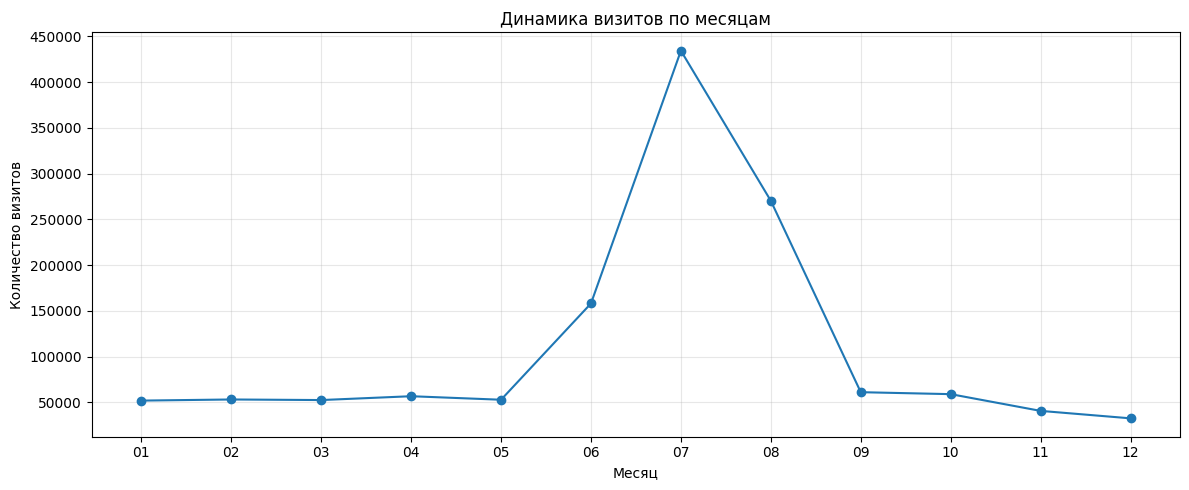

In [448]:
monthly["date"] = pd.to_datetime(monthly["date"])

plt.figure(figsize=(12, 5))

plt.plot(
    monthly["date"].dt.strftime("%m"),
    monthly["visits"],
    marker="o"
)

plt.title("Динамика визитов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество визитов")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [449]:
visits["weekday_num"] = visits["dateTime"].dt.dayofweek

weekday_names = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье"
}

visits["weekday"] = visits["weekday_num"].map(weekday_names)

weekday_stats = visits.groupby(
    ["weekday_num", "weekday"]
).agg(
    visits=("ym:s:visitID", "count"),
    avg_pageviews=("ym:s:pageViews", "mean"),
    avg_duration=("ym:s:visitDuration", "mean"),
    bounce_rate=("ym:s:bounce", "mean")
).reset_index()

weekday_stats["bounce_rate_%"] = weekday_stats["bounce_rate"] * 100

weekday_stats = weekday_stats.sort_values("weekday_num")

display(weekday_stats)

,weekday_num,weekday,visits,avg_pageviews,avg_duration,bounce_rate,bounce_rate_%
0,0,Понедельник,199502,2.931259,312.077698,0.100991,10.099147
1,1,Вторник,204248,2.952293,305.523471,0.101719,10.171948
2,2,Среда,208534,2.916129,310.965699,0.101609,10.160933
3,3,Четверг,201680,2.864736,314.301007,0.097660,9.765966
4,4,Пятница,195273,2.820119,330.441213,0.094883,9.488255
5,5,Суббота,169087,2.768462,328.416892,0.101096,10.109589
6,6,Воскресенье,145325,2.792906,271.699164,0.112286,11.228625


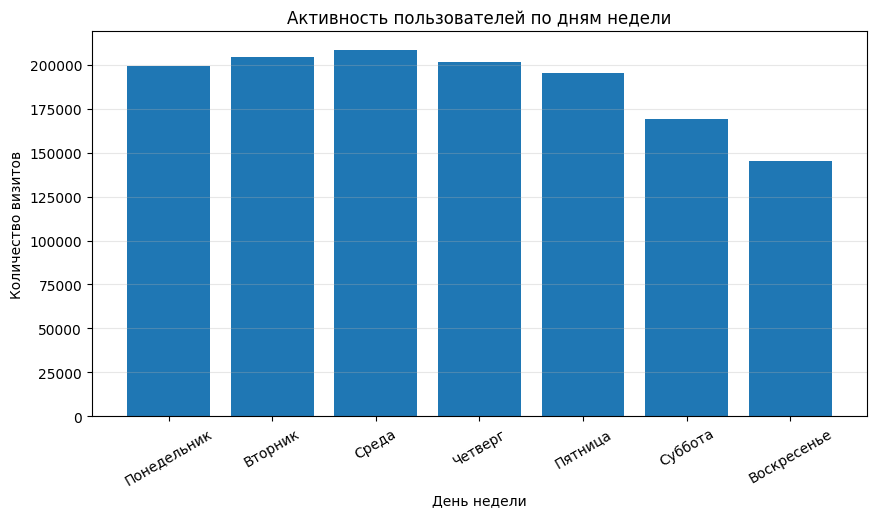

In [450]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_stats["weekday"],
    weekday_stats["visits"]
)

plt.title("Активность пользователей по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество визитов")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [451]:
visits["hour"] = visits["dateTime"].dt.hour

hour_stats = visits.groupby("hour").agg(
    visits=("ym:s:visitID", "count"),
    avg_pageviews=("ym:s:pageViews", "mean"),
    avg_duration=("ym:s:visitDuration", "mean"),
    bounce_rate=("ym:s:bounce", "mean")
).reset_index()

hour_stats["bounce_rate_%"] = hour_stats["bounce_rate"] * 100

display(hour_stats)

,hour,visits,avg_pageviews,avg_duration,bounce_rate,bounce_rate_%
0,0,37056,2.675005,231.881342,0.127726,12.772560
1,1,22942,2.500567,209.642185,0.115988,11.598814
2,2,16419,2.351300,192.136366,0.109934,10.993361
3,3,13653,2.225079,173.653702,0.101296,10.129642
4,4,12837,2.139519,172.789281,0.101192,10.119187
5,5,14384,2.190559,187.167547,0.095940,9.593993
6,6,19418,2.390823,229.431301,0.098002,9.800185
7,7,28388,2.497746,251.796428,0.099126,9.912639
8,8,43950,2.671081,293.835472,0.100364,10.036405
9,9,61257,2.855119,334.019002,0.098421,9.842140


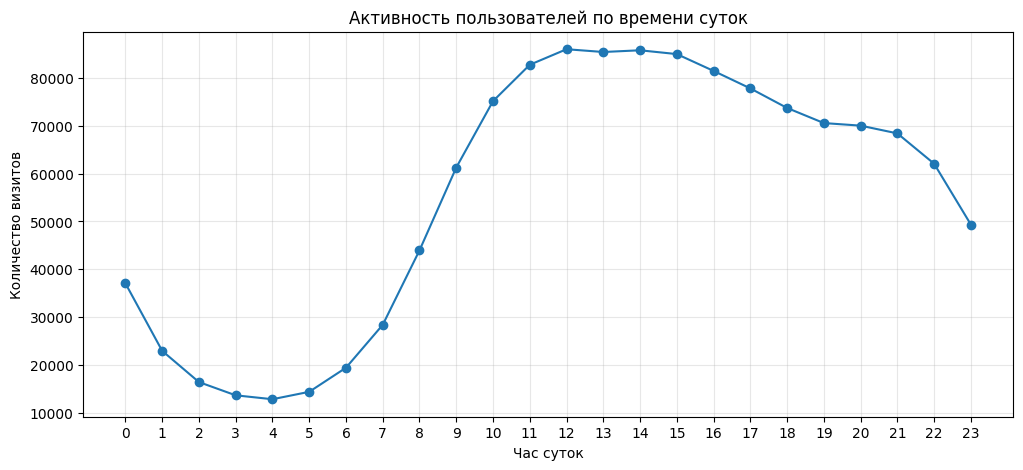

In [452]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_stats["hour"],
    hour_stats["visits"],
    marker="o"
)

plt.title("Активность пользователей по времени суток")
plt.xlabel("Час суток")
plt.ylabel("Количество визитов")

plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.show()

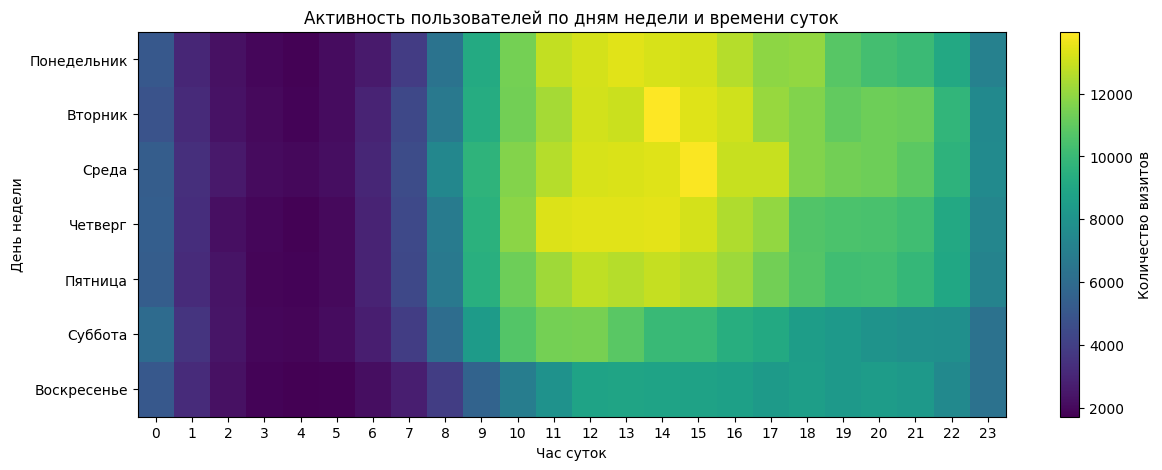

In [453]:
activity_heatmap = visits.pivot_table(
    index="weekday",
    columns="hour",
    values="ym:s:visitID",
    aggfunc="count",
    fill_value=0
)

activity_heatmap = activity_heatmap.loc[
    [
        "Понедельник",
        "Вторник",
        "Среда",
        "Четверг",
        "Пятница",
        "Суббота",
        "Воскресенье"
    ]
]

plt.figure(figsize=(14, 5))

plt.imshow(
    activity_heatmap,
    aspect="auto"
)

plt.title("Активность пользователей по дням недели и времени суток")
plt.xlabel("Час суток")
plt.ylabel("День недели")

plt.xticks(
    ticks=range(24),
    labels=range(24)
)

plt.yticks(
    ticks=range(len(activity_heatmap.index)),
    labels=activity_heatmap.index
)

plt.colorbar(label="Количество визитов")

plt.show()

In [454]:
device_stats = visits.groupby("device").agg(
    visits=("ym:s:visitID", "count"),
    avg_pageviews=("ym:s:pageViews", "mean"),
    avg_duration=("ym:s:visitDuration", "mean"),
    bounce_rate=("ym:s:bounce", "mean")
).reset_index()

device_stats["share_%"] = (
    device_stats["visits"] /
    device_stats["visits"].sum()
) * 100

device_stats["bounce_rate_%"] = (
    device_stats["bounce_rate"] * 100
)

display(
    device_stats.sort_values(
        "visits",
        ascending=False
    )
)

,device,visits,avg_pageviews,avg_duration,bounce_rate,share_%,bounce_rate_%
1,Mobile,806183,2.450793,240.941600,0.117284,60.906101,11.728354
0,Desktop,501847,3.542056,425.469946,0.072733,37.913903,7.273332
3,Tablet,15586,2.881817,299.177339,0.172912,1.177502,17.291159
2,TV,33,2.212121,393.030303,0.030303,0.002493,3.030303


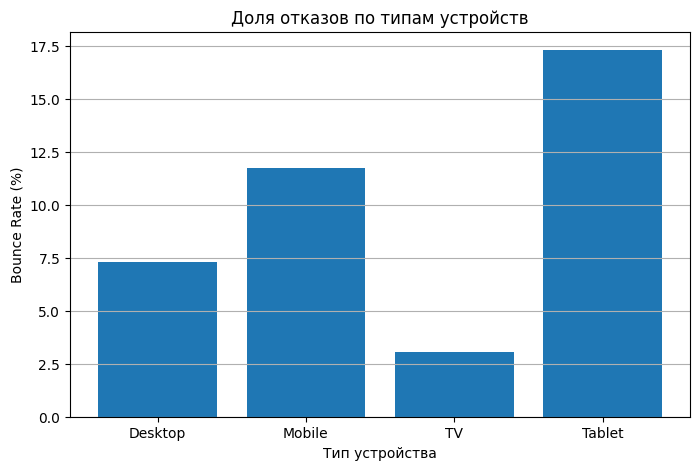

In [455]:
plt.figure(figsize=(8, 5))

plt.bar(
    device_stats["device"],
    device_stats["bounce_rate_%"]
)

plt.title("Доля отказов по типам устройств")

plt.xlabel("Тип устройства")

plt.ylabel("Bounce Rate (%)")

plt.grid(axis="y")

plt.show()

In [456]:
page_hits = hits[
    hits["ym:pv:isPageView"] == 1
]

top_pages = (
    page_hits["page"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_pages.columns = [
    "Страница",
    "Просмотры"
]

display(top_pages)

,Страница,Просмотры
0,priem.mai.ru/rating/,574041
1,priem.mai.ru/,547819
2,priem.mai.ru/base/programs/,353650
3,priem.mai.ru/news/item.php,184892
4,priem.mai.ru/list/,155115
5,priem.mai.ru/results/orders/2024.php,112039
6,priem.mai.ru/spec/programs/,100612
7,priem.mai.ru/bachelor/programs/,87375
8,priem.mai.ru/base/score/,54643
9,priem.mai.ru/contacts/,53287


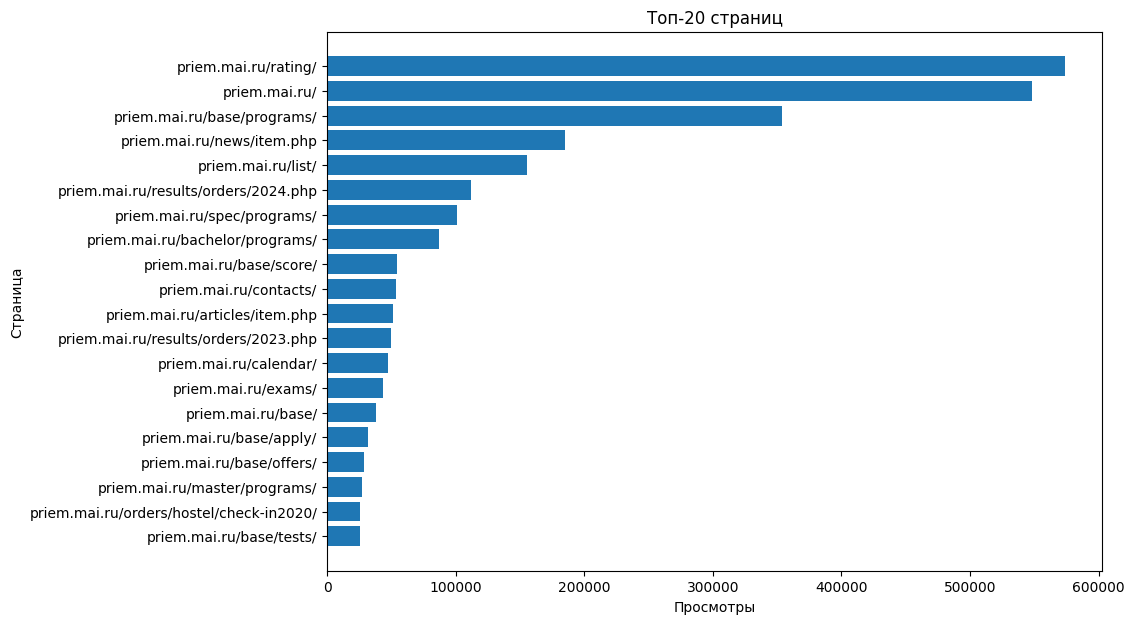

In [457]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_pages["Страница"][::-1],
    top_pages["Просмотры"][::-1]
)

plt.title("Топ-20 страниц")

plt.xlabel("Просмотры")

plt.ylabel("Страница")

plt.show()

In [458]:
page_hits["is_program_page"] = page_hits["page"].astype(str).str.lower().str.contains(
    "program|programs|base/programs",
    regex=True
)

total_views = len(page_hits)
program_views = page_hits["is_program_page"].sum()

program_share = program_views / total_views * 100

program_slide_df = pd.DataFrame({
    "Показатель": [
        "Все просмотры страниц",
        "Просмотры страниц программ",
        "Доля страниц программ"
    ],
    "Значение": [
        total_views,
        program_views,
        f"{program_share:.1f}%"
    ]
})

program_slide_df

,Показатель,Значение
0,Все просмотры страниц,3799123
1,Просмотры страниц программ,1235258
2,Доля страниц программ,32.5%


In [459]:
site_avg = pd.Series({
    "Средний показатель отказов": visits["ym:s:bounce"].mean() * 100,
    "Средняя глубина просмотра": visits["ym:s:pageViews"].mean(),
    "Средняя длительность визита": visits["ym:s:visitDuration"].mean()
})

program_visits = visits[
    visits["start_page"].astype(str).str.lower().str.contains(
        "program|programs|base/programs",
        regex=True
    )
]

program_avg = pd.Series({
    "Средний показатель отказов": program_visits["ym:s:bounce"].mean() * 100,
    "Средняя глубина просмотра": program_visits["ym:s:pageViews"].mean(),
    "Средняя длительность визита": program_visits["ym:s:visitDuration"].mean()
})

compare_programs_df = pd.DataFrame({
    "Метрика": site_avg.index,
    "В среднем по сайту": site_avg.values,
    "На страницах программ": program_avg.values
})

compare_programs_df["Отклонение"] = (
    compare_programs_df["На страницах программ"]
    - compare_programs_df["В среднем по сайту"]
)

compare_programs_df

,Метрика,В среднем по сайту,На страницах программ,Отклонение
0,Средний показатель отказов,10.104567,10.433303,0.328736
1,Средняя глубина просмотра,2.869603,2.526799,-0.342804
2,Средняя длительность визита,311.593017,225.776884,-85.816133


In [461]:
section_stats = (
    page_hits["section"]
    .value_counts()
    .head(20)
    .reset_index()
)

section_stats.columns = [
    "Раздел",
    "Просмотры"
]

display(section_stats)

,Раздел,Просмотры
0,base/programs,773749
1,rating,574112
2,Главная,547832
3,spec/programs,196136
4,news/item.php,184896
5,bachelor/programs,179592
6,results/orders,174581
7,list,155119
8,master/programs,56166
9,base/score,54699


In [462]:
program_keywords = [
    "program",
    "programs",
    "education/program",
    "bakalavriat",
    "magistratura"
]

page_hits["is_program_page"] = page_hits["page"].astype(str).str.lower().apply(
    lambda x: any(keyword in x for keyword in program_keywords)
)

program_pageviews = page_hits["is_program_page"].sum()

total_pageviews = len(page_hits)

program_share = program_pageviews / total_pageviews * 100

program_summary = pd.DataFrame({
    "Метрика": [
        "Всего просмотров страниц",
        "Просмотры страниц программ",
        "Доля просмотров программ, %"
    ],
    "Значение": [
        total_pageviews,
        program_pageviews,
        round(program_share, 2)
    ]
})

display(program_summary)

,Метрика,Значение
0,Всего просмотров страниц,3799123.00
1,Просмотры страниц программ,1235312.00
2,"Доля просмотров программ, %",32.52


In [463]:
top_start_pages = (
    visits["start_page"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_start_pages.columns = [
    "Стартовая страница",
    "Визиты"
]

display(top_start_pages)

,Стартовая страница,Визиты
0,priem.mai.ru/,277174
1,priem.mai.ru/rating/,239810
2,priem.mai.ru/news/item.php,100033
3,priem.mai.ru/list/,57056
4,priem.mai.ru/base/programs/,40611
5,priem.mai.ru/results/orders/2024.php,31113
6,priem.mai.ru/spec/programs/,29594
7,priem.mai.ru/bachelor/programs/,22998
8,priem.mai.ru/base/score/,19539
9,priem.mai.ru/articles/item.php,19104


In [464]:
top_exit_pages = (
    visits["end_page"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_exit_pages.columns = [
    "Страница выхода",
    "Визиты"
]

display(top_exit_pages)

,Страница выхода,Визиты
0,priem.mai.ru/rating/,276670
1,priem.mai.ru/,104248
2,priem.mai.ru/news/item.php,101849
3,priem.mai.ru/base/programs/,71700
4,priem.mai.ru/list/,63560
5,priem.mai.ru/results/orders/2024.php,38426
6,priem.mai.ru/contacts/,33140
7,priem.mai.ru/bachelor/programs/,26111
8,priem.mai.ru/spec/programs/,23993
9,priem.mai.ru/base/score/,23717


In [465]:
problem_pages = visits.groupby(
    "start_page"
).agg(
    visits=("start_page", "count"),
    bounce_rate=("ym:s:bounce", "mean"),
    avg_duration=("ym:s:visitDuration", "mean"),
    avg_pageviews=("ym:s:pageViews", "mean")
).reset_index()

problem_pages["bounce_rate_%"] = (
    problem_pages["bounce_rate"] * 100
)

problem_pages = problem_pages[
    problem_pages["visits"] >= 100
]

problem_pages = problem_pages.sort_values(
    "bounce_rate_%",
    ascending=False
)

display(problem_pages.head(30))

,start_page,visits,bounce_rate,avg_duration,avg_pageviews,bounce_rate_%
515,priem.mai.ru/foreign-applicants/,7938,0.493071,46.746284,1.353993,49.307130
736,priem.mai.ru/orders/testing/raspisanie-ekzamenov/,1865,0.432172,135.530295,2.197319,43.217158
361,priem.mai.ru/base/programs/proektirovanie-i-tekhnologiya-proizvodstva-la-setevaya-programma-mai-i-tikhookeanskogo-go...,8421,0.407909,60.765111,1.193445,40.790880
522,priem.mai.ru/foreign-applicants/bachelor/deadlines/,176,0.346591,39.698864,1.335227,34.659091
216,priem.mai.ru/base/achievements/,7847,0.322544,155.820696,1.644195,32.254365
421,priem.mai.ru/base/programs/teplovye-protsessy-v-aviatsionnoy-i-raketno-kosmicheskoy-tekhnike/,9651,0.304528,58.951715,1.261735,30.452803
545,priem.mai.ru/index.php,242,0.280992,280.768595,3.524793,28.099174
877,priem.mai.ru/spec/programs/programmnoe-obespechenie-sredstv-vychislitelnoy-tekhniki-i-avtomatizirovannykh-sistem/,150,0.273333,174.953333,2.533333,27.333333
904,priem.mai.ru/spec/programs/upravlenie-ekonomicheskoy-bezopasnostyu/,234,0.256410,183.670940,2.059829,25.641026
182,priem.mai.ru/bachelor/programs/item/tsifrovaya-ekonomika/,131,0.244275,52.740458,1.396947,24.427481


In [466]:
mobile_visits = visits[
    visits["device"] == "Mobile"
]

mobile_problem_pages = mobile_visits.groupby(
    "start_page"
).agg(
    visits=("start_page", "count"),
    bounce_rate=("ym:s:bounce", "mean"),
    avg_duration=("ym:s:visitDuration", "mean"),
    avg_pageviews=("ym:s:pageViews", "mean")
).reset_index()

mobile_problem_pages["bounce_rate_%"] = (
    mobile_problem_pages["bounce_rate"] * 100
)

mobile_problem_pages = mobile_problem_pages[
    mobile_problem_pages["visits"] >= 50
]

mobile_problem_pages = mobile_problem_pages.sort_values(
    "bounce_rate_%",
    ascending=False
)

display(mobile_problem_pages.head(30))

,start_page,visits,bounce_rate,avg_duration,avg_pageviews,bounce_rate_%
28,priem.mai.ru/bachelor/basiceducation/index.php,59,0.932203,0.220339,1.067797,93.220339
444,priem.mai.ru/master/programs/item/antikrizisnoe-upravlenie-i-konsalting/,51,0.666667,18.647059,1.137255,66.666667
489,priem.mai.ru/master/programs/item/perspektivnye-materialy-i-vysokoeffektivnye-tekhnologii/,50,0.560000,110.860000,1.100000,56.000000
400,priem.mai.ru/foreign-applicants/,7449,0.498322,40.305544,1.297490,49.832192
587,priem.mai.ru/orders/testing/raspisanie-ekzamenov/,1245,0.473092,110.263454,1.858635,47.309237
286,priem.mai.ru/base/programs/proektirovanie-i-tekhnologiya-proizvodstva-la-setevaya-programma-mai-i-tikhookeanskogo-go...,7463,0.412033,54.422082,1.180490,41.203269
407,priem.mai.ru/foreign-applicants/bachelor/deadlines/,164,0.353659,35.298780,1.189024,35.365854
668,priem.mai.ru/spec/programs/kiberbezopasnost-infokommunikatsiy/,52,0.326923,114.807692,2.596154,32.692308
424,priem.mai.ru/index.php,106,0.320755,200.896226,2.990566,32.075472
732,priem.mai.ru/spec/programs/upravlenie-ekonomicheskoy-bezopasnostyu/,135,0.311111,116.348148,1.651852,31.111111


In [467]:
traffic = visits.groupby(
    "ym:s:lastsignTrafficSource"
).agg(
    visits=("ym:s:lastsignTrafficSource", "count"),
    bounce_rate=("ym:s:bounce", "mean"),
    avg_duration=("ym:s:visitDuration", "mean")
).reset_index()

traffic["share_%"] = (
    traffic["visits"] /
    traffic["visits"].sum()
) * 100

traffic["bounce_rate_%"] = (
    traffic["bounce_rate"] * 100
)

display(
    traffic.sort_values(
        "visits",
        ascending=False
    )
)

,ym:s:lastsignTrafficSource,visits,bounce_rate,avg_duration,share_%,bounce_rate_%
5,organic,624897,0.079322,326.392044,47.210174,7.932187
8,referral,362392,0.075371,407.623452,27.378255,7.537142
1,direct,164194,0.165627,210.357942,12.404648,16.562725
0,ad,83730,0.241371,85.280795,6.325695,24.137107
3,internal,62843,0.108349,183.645259,4.747709,10.834938
10,social,17802,0.111560,265.951691,1.344918,11.156050
4,messenger,6586,0.066505,386.328120,0.497564,6.650471
6,qrcode,527,0.142315,110.210626,0.039814,14.231499
7,recommend,498,0.122490,349.767068,0.037623,12.248996
11,undefined,104,0.701923,107.192308,0.007857,70.192308


In [468]:
cities = visits.groupby(
    "ym:s:regionCity"
).agg(
    visits=("ym:s:regionCity", "count"),
    bounce_rate=("ym:s:bounce", "mean"),
    avg_duration=("ym:s:visitDuration", "mean")
).reset_index()

cities["bounce_rate_%"] = (
    cities["bounce_rate"] * 100
)

display(
    cities.sort_values(
        "visits",
        ascending=False
    ).head(20)
)

,ym:s:regionCity,visits,bounce_rate,avg_duration,bounce_rate_%
1085,Moscow,549174,0.104357,300.318429,10.435672
0,,251407,0.094838,305.776808,9.483825
1455,Saint Petersburg,54897,0.136109,277.153415,13.610944
1173,Nizhny Novgorod,27008,0.130517,298.677910,13.051688
435,Domodedovo,25312,0.146176,280.283699,14.617573
629,Helsinki,12489,0.028986,127.545680,2.898551
1739,Tver,11924,0.126719,316.983227,12.671922
643,Hong Kong,11910,0.024601,97.726868,2.460118
638,Himki,10383,0.094674,351.867572,9.467399
863,Krasnodar,9531,0.071556,368.730668,7.155598


In [469]:
downloads = hits[
    hits["ym:pv:download"] == 1
]

downloads = downloads.groupby(
    "page"
).size().reset_index(name="downloads")

display(
    downloads.sort_values(
        "downloads",
        ascending=False
    ).head(30)
)

,page,downloads
625,mai.ru/upload/iblock/5eb/gr08vbi82ngdi0e9rsw8sc1xxi6y8ugj/Obshchii_-konkurs.pdf,11808
564,mai.ru/upload/iblock/2cb/trcgbwsaexjra8opz9cwakaaxi0h2p5t/MAI-_1_.pdf,8789
717,mai.ru/upload/iblock/bf8/itu9nl4gqfl7er044ionlc5t86qc34ou/BVI_290706.pdf,4686
57,files.mai.ru/site/priem/documents/master/programs/maths.pdf,4582
16,files.mai.ru/site/education/points2022.pdf,4189
684,mai.ru/upload/iblock/9e5/kyah0jwxq50s8pnyv6d2gsi7w9j21d84/TSelevaya-kvota_290703.pdf,4080
588,mai.ru/upload/iblock/3f8/1ud4d3939rkmvclc2qhlawhqwb1x34vh/zachislenie-140803.pdf,3432
425,files.mai.ru/site/priem/documents/regulations/olymp24.pdf,2892
812,priem.mai.ru/upload/iblock/0ee/69o69ubrnhnzml3e6rbf7ktx245dsgur/01_03_02_Prikladnaya_matematika_i_informatika_kaf_80...,2853
987,priem.mai.ru/upload/iblock/800/viz5o45lorbywxjx1t739dx5i8p390na/02_03_02_Fundamentalnaya_informatika_i_informatsionn...,2613


In [470]:
transitions = visits.groupby(
    ["start_section", "end_section"]
).agg(
    visits=("start_section", "count")
).reset_index()

transitions = transitions.sort_values(
    "visits",
    ascending=False
)

display(transitions.head(30))

,start_section,end_section,visits
4498,rating,rating,208931
1216,base/programs,base/programs,134491
3306,news/item.php,news/item.php,87853
5650,Главная,Главная,85896
5551,Главная,base/programs,49511
478,bachelor/programs,bachelor/programs,48427
5086,spec/programs,spec/programs,43249
5626,Главная,rating,40519
2121,list,list,37689
4692,results/orders,results/orders,34317


In [471]:
main_transitions = transitions[
    transitions["start_section"] == "Главная"
]

main_transitions = main_transitions.sort_values(
    "visits",
    ascending=False
)

display(main_transitions.head(20))

,start_section,end_section,visits
5650,Главная,Главная,85896
5551,Главная,base/programs,49511
5626,Главная,rating,40519
5578,Главная,list,13314
5628,Главная,results/orders,9830
5558,Главная,contacts,8633
5540,Главная,bachelor/programs,7969
5637,Главная,spec/programs,6669
5606,Главная,news/item.php,6494
5557,Главная,calendar,4051


In [472]:
funnel_steps = {
    "Главная": "mai.ru",
    "Поступление": "priem",
    "Бакалавриат": "bachelor",
    "Программы": "program",
    "Документы": "order|rating|result"
}

funnel = []

for step_name, keyword in funnel_steps.items():

    count = visits[
        visits["ym:s:startURL"]
        .astype(str)
        .str.contains(
            keyword,
            case=False,
            na=False,
            regex=True
        )
        |
        visits["ym:s:endURL"]
        .astype(str)
        .str.contains(
            keyword,
            case=False,
            na=False,
            regex=True
        )
    ].shape[0]

    funnel.append({
        "Этап": step_name,
        "Визиты": count
    })

funnel = pd.DataFrame(funnel)

funnel["Конверсия от первого этапа, %"] = (
    funnel["Визиты"] /
    funnel["Визиты"].iloc[0]
) * 100

display(funnel)

,Этап,Визиты,"Конверсия от первого этапа, %"
0,Главная,1323649,100.000000
1,Поступление,1323649,100.000000
2,Бакалавриат,104815,7.918640
3,Программы,413569,31.244612
4,Документы,454976,34.372859


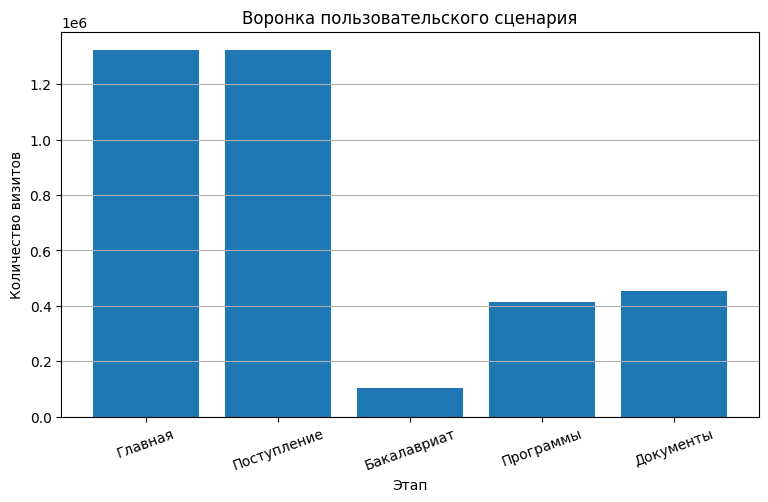

In [473]:
plt.figure(figsize=(9, 5))

plt.bar(
    funnel["Этап"],
    funnel["Визиты"]
)

plt.title("Воронка пользовательского сценария")

plt.xlabel("Этап")

plt.ylabel("Количество визитов")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

In [474]:
hypotheses = []

desktop_bounce = device_stats.loc[
    device_stats["device"] == "Desktop",
    "bounce_rate_%"
].iloc[0]

mobile_bounce = device_stats.loc[
    device_stats["device"] == "Mobile",
    "bounce_rate_%"
].iloc[0]

if mobile_bounce > desktop_bounce:

    hypotheses.append({
        "Проблема":
        "На мобильных устройствах доля отказов выше.",

        "Причина":
        "Мобильная навигация может быть неудобной.",

        "UX-гипотеза":
        "Упрощение мобильного меню снизит bounce rate."
    })

for _, row in problem_pages.head(10).iterrows():

    hypotheses.append({
        "Проблема":
        f"Страница {row['start_page']} имеет высокий bounce rate.",

        "Причина":
        "Пользователь не понимает следующий шаг.",

        "UX-гипотеза":
        "Добавление понятных CTA и улучшение структуры увеличит глубину просмотра."
    })

ux_hypotheses = pd.DataFrame(hypotheses)

display(ux_hypotheses)

,Проблема,Причина,UX-гипотеза
0,На мобильных устройствах доля отказов выше.,Мобильная навигация может быть неудобной.,Упрощение мобильного меню снизит bounce rate.
1,Страница priem.mai.ru/foreign-applicants/ имеет высокий bounce rate.,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.
2,Страница priem.mai.ru/orders/testing/raspisanie-ekzamenov/ имеет высокий bounce rate.,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.
3,Страница priem.mai.ru/base/programs/proektirovanie-i-tekhnologiya-proizvodstva-la-setevaya-programma-mai-i-tikhookea...,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.
4,Страница priem.mai.ru/foreign-applicants/bachelor/deadlines/ имеет высокий bounce rate.,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.
5,Страница priem.mai.ru/base/achievements/ имеет высокий bounce rate.,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.
6,Страница priem.mai.ru/base/programs/teplovye-protsessy-v-aviatsionnoy-i-raketno-kosmicheskoy-tekhnike/ имеет высокий...,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.
7,Страница priem.mai.ru/index.php имеет высокий bounce rate.,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.
8,Страница priem.mai.ru/spec/programs/programmnoe-obespechenie-sredstv-vychislitelnoy-tekhniki-i-avtomatizirovannykh-s...,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.
9,Страница priem.mai.ru/spec/programs/upravlenie-ekonomicheskoy-bezopasnostyu/ имеет высокий bounce rate.,Пользователь не понимает следующий шаг.,Добавление понятных CTA и улучшение структуры увеличит глубину просмотра.


In [475]:
problem_score = visits.groupby("start_page").agg(
    visits=("start_page", "count"),
    bounce_rate=("ym:s:bounce", "mean"),
    avg_duration=("ym:s:visitDuration", "mean"),
    avg_pageviews=("ym:s:pageViews", "mean")
).reset_index()

problem_score = problem_score[
    problem_score["visits"] >= 100
].copy()

problem_score["bounce_rate_%"] = problem_score["bounce_rate"] * 100

# Нормализация показателей
problem_score["bounce_norm"] = problem_score["bounce_rate_%"] / 100
problem_score["duration_norm"] = 1 - (
    problem_score["avg_duration"] / problem_score["avg_duration"].max()
)
problem_score["pageviews_norm"] = 1 - (
    problem_score["avg_pageviews"] / problem_score["avg_pageviews"].max()
)

problem_score["UX_problem_score"] = (
    problem_score["bounce_norm"] * 0.5 +
    problem_score["duration_norm"] * 0.3 +
    problem_score["pageviews_norm"] * 0.2
)

problem_score = problem_score.sort_values(
    "UX_problem_score",
    ascending=False
)

display(problem_score.head(20))

,start_page,visits,bounce_rate,avg_duration,avg_pageviews,bounce_rate_%,bounce_norm,duration_norm,pageviews_norm,UX_problem_score
515,priem.mai.ru/foreign-applicants/,7938,0.493071,46.746284,1.353993,49.307130,0.493071,0.943849,0.848635,0.699417
361,priem.mai.ru/base/programs/proektirovanie-i-tekhnologiya-proizvodstva-la-setevaya-programma-mai-i-tikhookeanskogo-go...,8421,0.407909,60.765111,1.193445,40.790880,0.407909,0.927009,0.866583,0.655374
522,priem.mai.ru/foreign-applicants/bachelor/deadlines/,176,0.346591,39.698864,1.335227,34.659091,0.346591,0.952314,0.850733,0.629136
736,priem.mai.ru/orders/testing/raspisanie-ekzamenov/,1865,0.432172,135.530295,2.197319,43.217158,0.432172,0.837202,0.754358,0.618118
421,priem.mai.ru/base/programs/teplovye-protsessy-v-aviatsionnoy-i-raketno-kosmicheskoy-tekhnike/,9651,0.304528,58.951715,1.261735,30.452803,0.304528,0.929188,0.858949,0.602810
182,priem.mai.ru/bachelor/programs/item/tsifrovaya-ekonomika/,131,0.244275,52.740458,1.396947,24.427481,0.244275,0.936649,0.843833,0.571899
216,priem.mai.ru/base/achievements/,7847,0.322544,155.820696,1.644195,32.254365,0.322544,0.812830,0.816193,0.568359
109,priem.mai.ru/bachelor/programs/item/inzhenernoe-delo-v-mediko-biologicheskoy-praktike-i-biotekhnicheskikh-sistemakh/,160,0.225000,109.137500,1.368750,22.500000,0.225000,0.868905,0.846985,0.542569
833,priem.mai.ru/spec/programs/item/,204,0.196078,60.897059,1.563725,19.607843,0.196078,0.926851,0.825188,0.541132
185,priem.mai.ru/bachelor/programs/item/upravlenie-gosudarstvennoy-i-munitsipalnoy-sobstvennostyu/,129,0.240310,130.116279,1.751938,24.031008,0.240310,0.843705,0.804148,0.534096


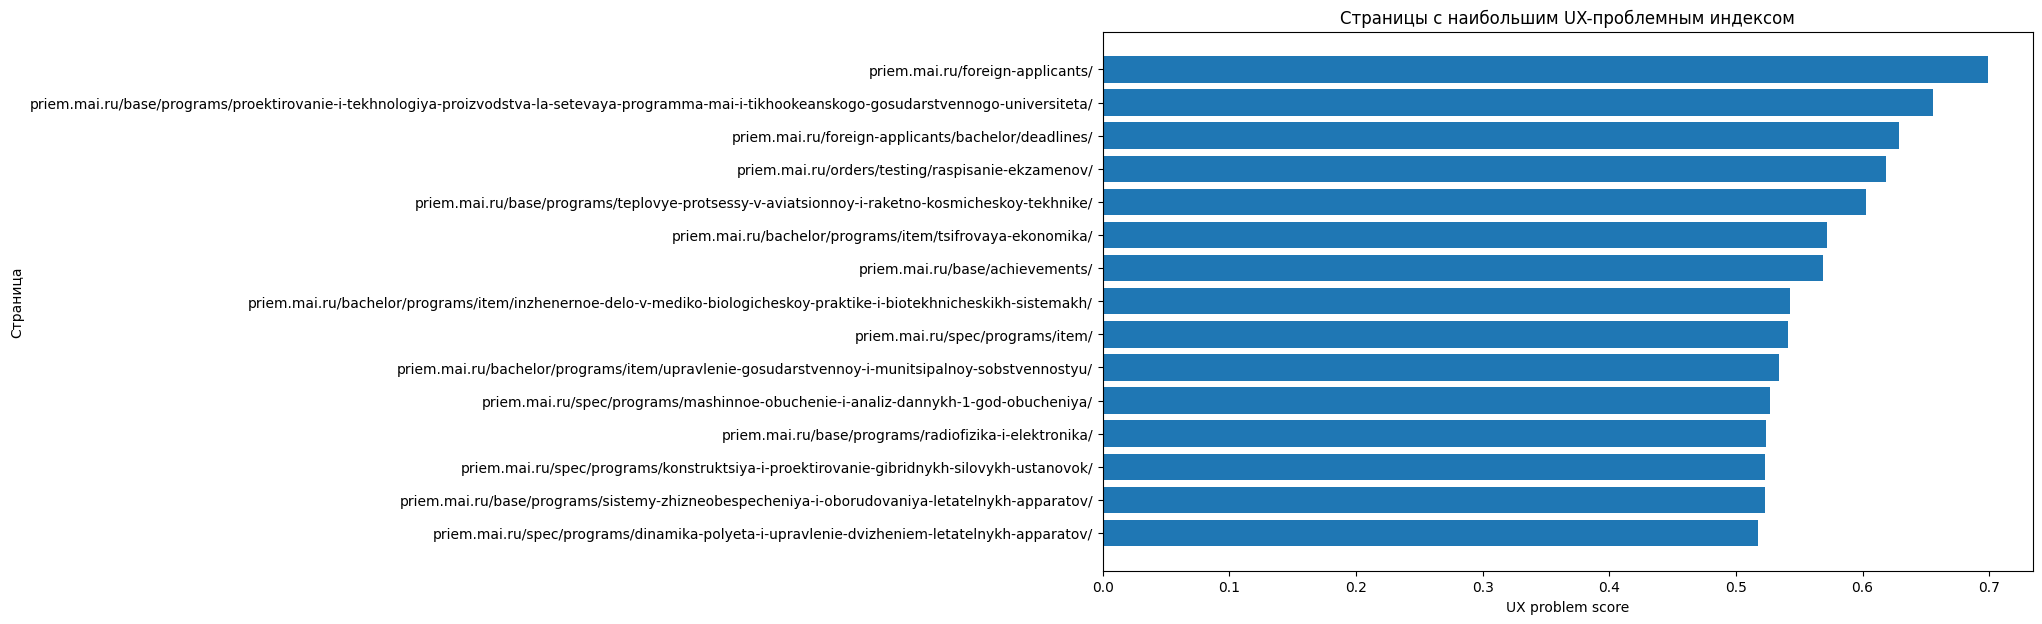

In [476]:
top_problem_score = problem_score.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_problem_score["start_page"][::-1],
    top_problem_score["UX_problem_score"][::-1]
)

plt.title("Страницы с наибольшим UX-проблемным индексом")
plt.xlabel("UX problem score")
plt.ylabel("Страница")

plt.show()

In [477]:
site_avg_bounce = visits["ym:s:bounce"].mean() * 100
site_avg_duration = visits["ym:s:visitDuration"].mean()
site_avg_pageviews = visits["ym:s:pageViews"].mean()

problem_pages_relative = problem_pages.copy()

problem_pages_relative["bounce_vs_site_pp"] = (
    problem_pages_relative["bounce_rate_%"] - site_avg_bounce
)

problem_pages_relative["duration_vs_site_%"] = (
    (
        problem_pages_relative["avg_duration"] - site_avg_duration
    )
    / site_avg_duration
    * 100
)

problem_pages_relative["pageviews_vs_site_%"] = (
    (
        problem_pages_relative["avg_pageviews"] - site_avg_pageviews
    )
    / site_avg_pageviews
    * 100
)

problem_pages_relative[
    [
        "start_page",
        "visits",
        "bounce_rate_%",
        "bounce_vs_site_pp",
        "avg_duration",
        "duration_vs_site_%",
        "avg_pageviews",
        "pageviews_vs_site_%"
    ]
].head(20)

,start_page,visits,bounce_rate_%,bounce_vs_site_pp,avg_duration,duration_vs_site_%,avg_pageviews,pageviews_vs_site_%
515,priem.mai.ru/foreign-applicants/,7938,49.307130,39.202563,46.746284,-84.997647,1.353993,-52.815999
736,priem.mai.ru/orders/testing/raspisanie-ekzamenov/,1865,43.217158,33.112591,135.530295,-56.504065,2.197319,-23.427766
361,priem.mai.ru/base/programs/proektirovanie-i-tekhnologiya-proizvodstva-la-setevaya-programma-mai-i-tikhookeanskogo-go...,8421,40.790880,30.686313,60.765111,-80.498565,1.193445,-58.410797
522,priem.mai.ru/foreign-applicants/bachelor/deadlines/,176,34.659091,24.554524,39.698864,-87.259386,1.335227,-53.469964
216,priem.mai.ru/base/achievements/,7847,32.254365,22.149798,155.820696,-49.992238,1.644195,-42.703040
421,priem.mai.ru/base/programs/teplovye-protsessy-v-aviatsionnoy-i-raketno-kosmicheskoy-tekhnike/,9651,30.452803,20.348236,58.951715,-81.080540,1.261735,-56.031040
545,priem.mai.ru/index.php,242,28.099174,17.994607,280.768595,-9.892527,3.524793,22.832096
877,priem.mai.ru/spec/programs/programmnoe-obespechenie-sredstv-vychislitelnoy-tekhniki-i-avtomatizirovannykh-sistem/,150,27.333333,17.228766,174.953333,-43.851972,2.533333,-11.718331
904,priem.mai.ru/spec/programs/upravlenie-ekonomicheskoy-bezopasnostyu/,234,25.641026,15.536459,183.670940,-41.054218,2.059829,-28.219021
182,priem.mai.ru/bachelor/programs/item/tsifrovaya-ekonomika/,131,24.427481,14.322914,52.740458,-83.073928,1.396947,-51.319168


In [479]:
critical_pages = problem_score.head(20).copy()

critical_pages = critical_pages.sort_values(
    ["bounce_rate_%", "avg_duration"],
    ascending=[False, True]
)

display(
    critical_pages[
        [
            "start_page",
            "visits",
            "bounce_rate_%",
            "avg_duration",
            "avg_pageviews",
            "UX_problem_score"
        ]
    ].head(20)
)

,start_page,visits,bounce_rate_%,avg_duration,avg_pageviews,UX_problem_score
515,priem.mai.ru/foreign-applicants/,7938,49.307130,46.746284,1.353993,0.699417
736,priem.mai.ru/orders/testing/raspisanie-ekzamenov/,1865,43.217158,135.530295,2.197319,0.618118
361,priem.mai.ru/base/programs/proektirovanie-i-tekhnologiya-proizvodstva-la-setevaya-programma-mai-i-tikhookeanskogo-go...,8421,40.790880,60.765111,1.193445,0.655374
522,priem.mai.ru/foreign-applicants/bachelor/deadlines/,176,34.659091,39.698864,1.335227,0.629136
216,priem.mai.ru/base/achievements/,7847,32.254365,155.820696,1.644195,0.568359
421,priem.mai.ru/base/programs/teplovye-protsessy-v-aviatsionnoy-i-raketno-kosmicheskoy-tekhnike/,9651,30.452803,58.951715,1.261735,0.602810
877,priem.mai.ru/spec/programs/programmnoe-obespechenie-sredstv-vychislitelnoy-tekhniki-i-avtomatizirovannykh-sistem/,150,27.333333,174.953333,2.533333,0.516980
904,priem.mai.ru/spec/programs/upravlenie-ekonomicheskoy-bezopasnostyu/,234,25.641026,183.670940,2.059829,0.515964
182,priem.mai.ru/bachelor/programs/item/tsifrovaya-ekonomika/,131,24.427481,52.740458,1.396947,0.571899
124,priem.mai.ru/bachelor/programs/item/materialovedenie-i-tekhnologiya-novykh-materialov/,124,24.193548,182.935484,1.782258,0.515197


,bachelor/programs,base/programs,base/score,list,master/programs,news/item.php,rating,results/orders,spec/programs,Главная
start_section,,,,,,,,,,
bachelor/programs,48427,35,28,101,674,623,19,1948,12,490
base/programs,12,134491,711,1237,1,446,3083,2279,1513,2872
base/score,0,1603,14874,164,0,61,396,262,75,323
list,16,1398,222,37689,3,115,10435,1734,353,1541
master/programs,629,6,2,35,15307,169,15,573,0,178
news/item.php,1224,1409,184,144,222,87853,505,439,372,1511
rating,23,3920,492,6068,6,451,208931,5658,804,4059
results/orders,80,803,116,1725,19,238,4253,34317,185,1165
spec/programs,1,1783,97,687,0,162,1549,790,43249,1148


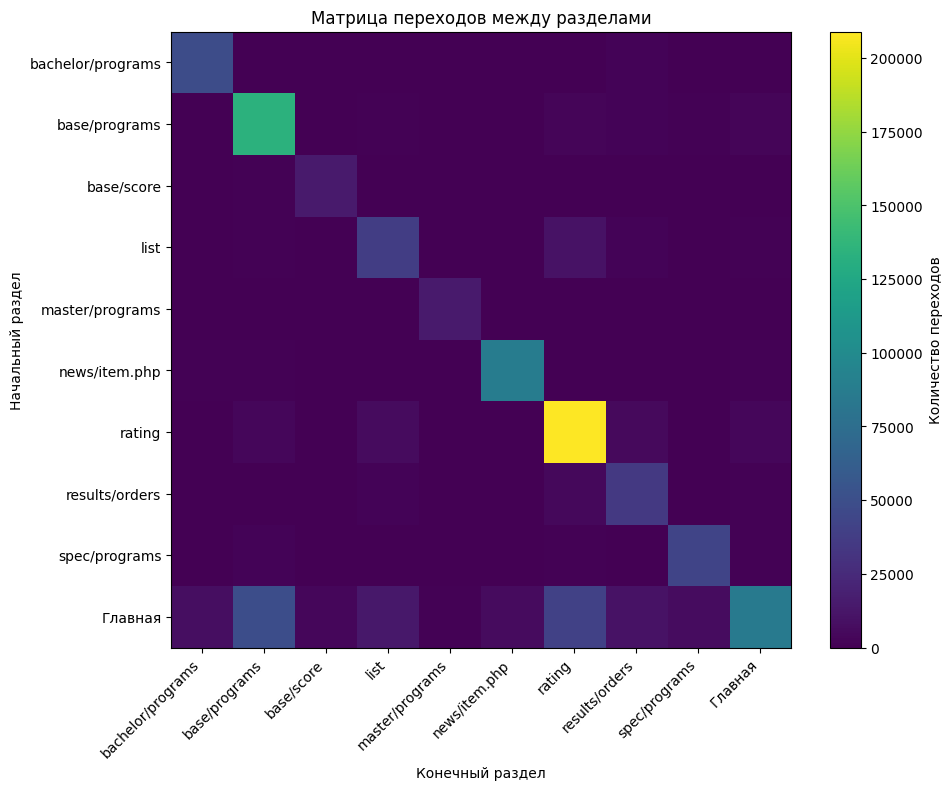

In [480]:
transition_matrix = pd.crosstab(
    visits["start_section"],
    visits["end_section"]
)

# Берём только самые популярные разделы
top_sections = (
    visits["start_section"]
    .value_counts()
    .head(10)
    .index
)

transition_matrix_top = transition_matrix.loc[
    transition_matrix.index.intersection(top_sections),
    transition_matrix.columns.intersection(top_sections)
]

display(transition_matrix_top)

plt.figure(figsize=(10, 8))

plt.imshow(transition_matrix_top, aspect="auto")

plt.title("Матрица переходов между разделами")
plt.xlabel("Конечный раздел")
plt.ylabel("Начальный раздел")

plt.xticks(
    range(len(transition_matrix_top.columns)),
    transition_matrix_top.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(transition_matrix_top.index)),
    transition_matrix_top.index
)

plt.colorbar(label="Количество переходов")

plt.show()

In [497]:
import plotly.graph_objects as go

sankey_data = visits.groupby(
    ["start_section", "end_section"]
).size().reset_index(name="count")

sankey_data = sankey_data[
    sankey_data["start_section"].notna() &
    sankey_data["end_section"].notna() &
    (sankey_data["start_section"] != sankey_data["end_section"])
]

sankey_data = sankey_data.sort_values(
    "count",
    ascending=False
).head(20)

labels = list(
    pd.unique(
        sankey_data[["start_section", "end_section"]].values.ravel()
    )
)

label_to_id = {
    label: i
    for i, label in enumerate(labels)
}

source = sankey_data["start_section"].map(label_to_id)
target = sankey_data["end_section"].map(label_to_id)
value = sankey_data["count"]

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=labels,
                pad=15,
                thickness=20
            ),
            link=dict(
                source=source,
                target=target,
                value=value
            )
        )
    ]
)

fig.update_layout(
    title_text="Sankey-диаграмма пользовательских переходов",
    font_size=10
)

fig.show()

In [504]:
key_sections = [
    "home",
    "base/programs",
    "rating",
    "list",
    "orders"
]

path_visits = visits[
    visits["start_section"].isin(key_sections)
    & visits["end_section"].isin(key_sections)
].copy()

path_matrix = path_visits.groupby(
    ["start_section", "end_section"]
).size().reset_index(name="transitions")

total_key_transitions = path_matrix["transitions"].sum()

path_matrix["share_%"] = (
    path_matrix["transitions"] / total_key_transitions * 100
)

path_matrix = path_matrix.sort_values(
    "transitions",
    ascending=False
)

path_matrix.head(10)

,start_section,end_section,transitions,share_%
8,rating,rating,208931,51.302633
0,base/programs,base/programs,134491,33.024024
4,list,list,37689,9.254467
5,list,rating,10435,2.562296
7,rating,list,6068,1.489987
6,rating,base/programs,3920,0.962549
2,base/programs,rating,3083,0.757025
3,list,base/programs,1398,0.343276
1,base/programs,list,1237,0.303743


In [505]:
competition_sections = ["rating", "list", "orders"]

program_to_competition = visits[
    (visits["start_section"] == "base/programs")
    & (visits["end_section"].isin(competition_sections))
]

program_starts = visits[
    visits["start_section"] == "base/programs"
]

program_to_competition_share = (
    len(program_to_competition) / len(program_starts) * 100
)

program_path_df = pd.DataFrame({
    "Что проверяем": [
        "Переходы из программ в конкурсные разделы",
        "Все выходы/переходы со страниц программ",
        "Доля переходов в rating/list/orders"
    ],
    "Значение": [
        len(program_to_competition),
        len(program_starts),
        f"{program_to_competition_share:.1f}%"
    ]
})

program_path_df

,Что проверяем,Значение
0,Переходы из программ в конкурсные разделы,4320
1,Все выходы/переходы со страниц программ,165287
2,Доля переходов в rating/list/orders,2.6%


In [482]:
device_page_stats = visits.groupby(
    ["start_page", "device"]
).agg(
    visits=("start_page", "count"),
    bounce_rate=("ym:s:bounce", "mean"),
    avg_duration=("ym:s:visitDuration", "mean"),
    avg_pageviews=("ym:s:pageViews", "mean")
).reset_index()

device_page_stats["bounce_rate_%"] = (
    device_page_stats["bounce_rate"] * 100
)

device_pivot = device_page_stats.pivot_table(
    index="start_page",
    columns="device",
    values="bounce_rate_%",
    aggfunc="mean"
).reset_index()

device_pivot = device_pivot.dropna(
    subset=["Desktop", "Mobile"],
    how="any"
)

device_pivot["mobile_minus_desktop"] = (
    device_pivot["Mobile"] - device_pivot["Desktop"]
)

device_pivot = device_pivot.sort_values(
    "mobile_minus_desktop",
    ascending=False
)

display(device_pivot.head(20))

device,start_page,Desktop,Mobile,TV,Tablet,mobile_minus_desktop
352,priem.mai.ru/base/programs/perevod-i-perevodovedenie-v-aerokosmicheskoy-otrasli/www.aeroflot.ru,0.000000,100.000000,NaN,NaN,100.000000
173,priem.mai.ru/bachelor/programs/item/sotsialnye-tekhnologii/,0.000000,100.000000,NaN,NaN,100.000000
60,priem.mai.ru/bachelor/dod/,0.000000,100.000000,NaN,NaN,100.000000
405,priem.mai.ru/base/programs/sistemy-upravleniya-bespilotnymi-letatelnymi-apparatami/www.mars-mokb.ru,0.000000,100.000000,NaN,NaN,100.000000
220,priem.mai.ru/base/apply//,0.000000,100.000000,NaN,NaN,100.000000
935,priem.mai.ru/theme24.php,0.000000,100.000000,NaN,NaN,100.000000
941,priem.mai.ru/upload/iblock/004/24.04.05-Raschet-i-proektirovanie-perspektivnykh-VRD.pdf,0.000000,100.000000,NaN,NaN,100.000000
454,priem.mai.ru/base/programs/vychislitelnaya-i-eksperimentalnaya-aerogidrodinamika-letatelnykh-apparatov/index.php,0.000000,100.000000,NaN,NaN,100.000000
224,priem.mai.ru/base/apply/online/,0.000000,100.000000,NaN,NaN,100.000000
554,priem.mai.ru/lists/,0.000000,100.000000,NaN,100.0,100.000000


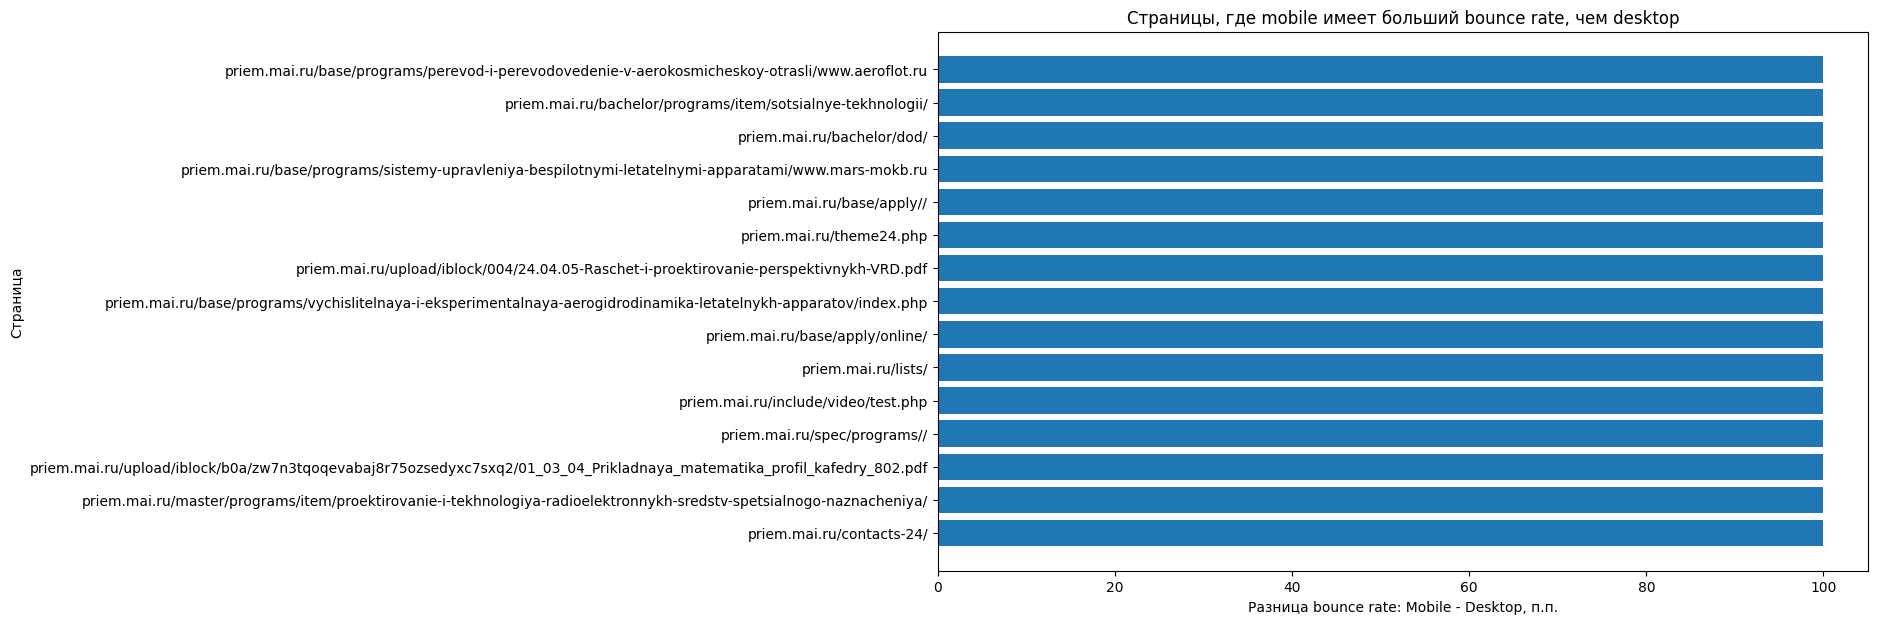

In [483]:
mobile_worse = device_pivot.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    mobile_worse["start_page"][::-1],
    mobile_worse["mobile_minus_desktop"][::-1]
)

plt.title("Страницы, где mobile имеет больший bounce rate, чем desktop")
plt.xlabel("Разница bounce rate: Mobile - Desktop, п.п.")
plt.ylabel("Страница")

plt.show()

In [484]:
ux_argument_rows = []

for _, row in critical_pages.head(10).iterrows():
    ux_argument_rows.append({
        "Страница": row["start_page"],
        "Данные": (
            f"Bounce rate: {row['bounce_rate_%']:.1f}%, "
            f"средняя длительность: {row['avg_duration']:.1f} сек., "
            f"глубина просмотра: {row['avg_pageviews']:.2f}"
        ),
        "UX-проблема": (
            "Пользователь быстро покидает страницу и не переходит дальше."
        ),
        "Возможная причина": (
            "Недостаточно понятная структура страницы, слабая визуальная иерархия "
            "или отсутствие очевидного следующего действия."
        ),
        "UX-гипотеза": (
            "Если упростить первый экран, выделить ключевые действия и структурировать "
            "контент по сценариям пользователя, глубина просмотра увеличится, "
            "а доля отказов снизится."
        ),
        "Решение в интерфейсе": (
            "Добавить CTA-кнопки, карточки сценариев, блок «Что делать дальше», "
            "улучшить навигацию и визуальную иерархию."
        )
    })

ux_arguments = pd.DataFrame(ux_argument_rows)

display(ux_arguments)

,Страница,Данные,UX-проблема,Возможная причина,UX-гипотеза,Решение в интерфейсе
0,priem.mai.ru/foreign-applicants/,"Bounce rate: 49.3%, средняя длительность: 46.7 сек., глубина просмотра: 1.35",Пользователь быстро покидает страницу и не переходит дальше.,"Недостаточно понятная структура страницы, слабая визуальная иерархия или отсутствие очевидного следующего действия.","Если упростить первый экран, выделить ключевые действия и структурировать контент по сценариям пользователя, глубина...","Добавить CTA-кнопки, карточки сценариев, блок «Что делать дальше», улучшить навигацию и визуальную иерархию."
1,priem.mai.ru/orders/testing/raspisanie-ekzamenov/,"Bounce rate: 43.2%, средняя длительность: 135.5 сек., глубина просмотра: 2.20",Пользователь быстро покидает страницу и не переходит дальше.,"Недостаточно понятная структура страницы, слабая визуальная иерархия или отсутствие очевидного следующего действия.","Если упростить первый экран, выделить ключевые действия и структурировать контент по сценариям пользователя, глубина...","Добавить CTA-кнопки, карточки сценариев, блок «Что делать дальше», улучшить навигацию и визуальную иерархию."
2,priem.mai.ru/base/programs/proektirovanie-i-tekhnologiya-proizvodstva-la-setevaya-programma-mai-i-tikhookeanskogo-go...,"Bounce rate: 40.8%, средняя длительность: 60.8 сек., глубина просмотра: 1.19",Пользователь быстро покидает страницу и не переходит дальше.,"Недостаточно понятная структура страницы, слабая визуальная иерархия или отсутствие очевидного следующего действия.","Если упростить первый экран, выделить ключевые действия и структурировать контент по сценариям пользователя, глубина...","Добавить CTA-кнопки, карточки сценариев, блок «Что делать дальше», улучшить навигацию и визуальную иерархию."
3,priem.mai.ru/foreign-applicants/bachelor/deadlines/,"Bounce rate: 34.7%, средняя длительность: 39.7 сек., глубина просмотра: 1.34",Пользователь быстро покидает страницу и не переходит дальше.,"Недостаточно понятная структура страницы, слабая визуальная иерархия или отсутствие очевидного следующего действия.","Если упростить первый экран, выделить ключевые действия и структурировать контент по сценариям пользователя, глубина...","Добавить CTA-кнопки, карточки сценариев, блок «Что делать дальше», улучшить навигацию и визуальную иерархию."
4,priem.mai.ru/base/achievements/,"Bounce rate: 32.3%, средняя длительность: 155.8 сек., глубина просмотра: 1.64",Пользователь быстро покидает страницу и не переходит дальше.,"Недостаточно понятная структура страницы, слабая визуальная иерархия или отсутствие очевидного следующего действия.","Если упростить первый экран, выделить ключевые действия и структурировать контент по сценариям пользователя, глубина...","Добавить CTA-кнопки, карточки сценариев, блок «Что делать дальше», улучшить навигацию и визуальную иерархию."
5,priem.mai.ru/base/programs/teplovye-protsessy-v-aviatsionnoy-i-raketno-kosmicheskoy-tekhnike/,"Bounce rate: 30.5%, средняя длительность: 59.0 сек., глубина просмотра: 1.26",Пользователь быстро покидает страницу и не переходит дальше.,"Недостаточно понятная структура страницы, слабая визуальная иерархия или отсутствие очевидного следующего действия.","Если упростить первый экран, выделить ключевые действия и структурировать контент по сценариям пользователя, глубина...","Добавить CTA-кнопки, карточки сценариев, блок «Что делать дальше», улучшить навигацию и визуальную иерархию."
6,priem.mai.ru/spec/programs/programmnoe-obespechenie-sredstv-vychislitelnoy-tekhniki-i-avtomatizirovannykh-sistem/,"Bounce rate: 27.3%, средняя длительность: 175.0 сек., глубина просмотра: 2.53",Пользователь быстро покидает страницу и не переходит дальше.,"Недостаточно понятная структура страницы, слабая визуальная иерархия или отсутствие очевидного следующего действия.","Если упростить первый экран, выделить ключевые действия и структурировать контент по сценариям пользователя, глубина...","Добавить CTA-кнопки, карточки сценариев, блок «Что делать дальше», улучшить навиг

In [485]:
mobile_arguments = []

for _, row in device_pivot.head(10).iterrows():
    mobile_arguments.append({
        "Страница": row["start_page"],
        "Данные": (
            f"Bounce rate mobile выше desktop на "
            f"{row['mobile_minus_desktop']:.1f} п.п."
        ),
        "UX-проблема": (
            "Мобильным пользователям сложнее продолжить сценарий."
        ),
        "Возможная причина": (
            "Интерфейс недостаточно адаптирован под мобильный экран: "
            "мелкие элементы, сложная навигация, перегруженные блоки."
        ),
        "UX-гипотеза": (
            "Если адаптировать страницу под мобильные сценарии, "
            "сделать крупные CTA и упростить меню, показатель отказов снизится."
        ),
        "Решение в интерфейсе": (
            "Мобильное меню, крупные кнопки, карточная структура, "
            "сокращение длинных таблиц и текстовых блоков."
        )
    })

mobile_ux_arguments = pd.DataFrame(mobile_arguments)

display(mobile_ux_arguments)

,Страница,Данные,UX-проблема,Возможная причина,UX-гипотеза,Решение в интерфейсе
0,priem.mai.ru/base/programs/perevod-i-perevodovedenie-v-aerokosmicheskoy-otrasli/www.aeroflot.ru,Bounce rate mobile выше desktop на 100.0 п.п.,Мобильным пользователям сложнее продолжить сценарий.,"Интерфейс недостаточно адаптирован под мобильный экран: мелкие элементы, сложная навигация, перегруженные блоки.","Если адаптировать страницу под мобильные сценарии, сделать крупные CTA и упростить меню, показатель отказов снизится.","Мобильное меню, крупные кнопки, карточная структура, сокращение длинных таблиц и текстовых блоков."
1,priem.mai.ru/bachelor/programs/item/sotsialnye-tekhnologii/,Bounce rate mobile выше desktop на 100.0 п.п.,Мобильным пользователям сложнее продолжить сценарий.,"Интерфейс недостаточно адаптирован под мобильный экран: мелкие элементы, сложная навигация, перегруженные блоки.","Если адаптировать страницу под мобильные сценарии, сделать крупные CTA и упростить меню, показатель отказов снизится.","Мобильное меню, крупные кнопки, карточная структура, сокращение длинных таблиц и текстовых блоков."
2,priem.mai.ru/bachelor/dod/,Bounce rate mobile выше desktop на 100.0 п.п.,Мобильным пользователям сложнее продолжить сценарий.,"Интерфейс недостаточно адаптирован под мобильный экран: мелкие элементы, сложная навигация, перегруженные блоки.","Если адаптировать страницу под мобильные сценарии, сделать крупные CTA и упростить меню, показатель отказов снизится.","Мобильное меню, крупные кнопки, карточная структура, сокращение длинных таблиц и текстовых блоков."
3,priem.mai.ru/base/programs/sistemy-upravleniya-bespilotnymi-letatelnymi-apparatami/www.mars-mokb.ru,Bounce rate mobile выше desktop на 100.0 п.п.,Мобильным пользователям сложнее продолжить сценарий.,"Интерфейс недостаточно адаптирован под мобильный экран: мелкие элементы, сложная навигация, перегруженные блоки.","Если адаптировать страницу под мобильные сценарии, сделать крупные CTA и упростить меню, показатель отказов снизится.","Мобильное меню, крупные кнопки, карточная структура, сокращение длинных таблиц и текстовых блоков."
4,priem.mai.ru/base/apply//,Bounce rate mobile выше desktop на 100.0 п.п.,Мобильным пользователям сложнее продолжить сценарий.,"Интерфейс недостаточно адаптирован под мобильный экран: мелкие элементы, сложная навигация, перегруженные блоки.","Если адаптировать страницу под мобильные сценарии, сделать крупные CTA и упростить меню, показатель отказов снизится.","Мобильное меню, крупные кнопки, карточная структура, сокращение длинных таблиц и текстовых блоков."
5,priem.mai.ru/theme24.php,Bounce rate mobile выше desktop на 100.0 п.п.,Мобильным пользователям сложнее продолжить сценарий.,"Интерфейс недостаточно адаптирован под мобильный экран: мелкие элементы, сложная навигация, перегруженные блоки.","Если адаптировать страницу под мобильные сценарии, сделать крупные CTA и упростить меню, показатель отказов снизится.","Мобильное меню, крупные кнопки, карточная структура, сокращение длинных таблиц и текстовых блоков."
6,priem.mai.ru/upload/iblock/004/24.04.05-Raschet-i-proektirovanie-perspektivnykh-VRD.pdf,Bounce rate mobile выше desktop на 100.0 п.п.,Мобильным пользователям сложнее продолжить сценарий.,"Интерфейс недостаточно адаптирован под мобильный экран: мелкие элементы, сложная навигация, перегруженные блоки.","Если адаптировать страницу под мобильные сценарии, сделать крупные CTA и упростить меню, показатель отказов снизится.","Мобильное меню, крупные кнопки, карточная структура, сокращение длинных таблиц и текстовых блоков."
7,priem.mai.ru/base/programs/vychislitelnaya-i-eksperimentalnaya-aerogidrodinamika-letatelnykh-apparatov/index.php,Bounce rate mobile выше desktop на 100.0 п.п.,Мобильным пользователям сложнее продолжить сценарий.,"Интерфейс недостаточно адаптирован под мобильный экран: мелкие элементы, сложная навигация, перегруженные блоки.","Если адаптировать страницу под мобильные сценарии, сделать крупные CTA и упростить меню, показатель отказов с

In [486]:
device_compare = device_stats[
    device_stats["device"].isin(["Mobile", "Desktop"])
].copy()

device_compare = device_compare[
    [
        "device",
        "visits",
        "share_%",
        "bounce_rate_%",
        "avg_pageviews",
        "avg_duration"
    ]
]

display(device_compare)

,device,visits,share_%,bounce_rate_%,avg_pageviews,avg_duration
0,Desktop,501847,37.913903,7.273332,3.542056,425.469946
1,Mobile,806183,60.906101,11.728354,2.450793,240.941600


In [487]:
mobile = device_compare[device_compare["device"] == "Mobile"].iloc[0]
desktop = device_compare[device_compare["device"] == "Desktop"].iloc[0]

mobile_desktop_summary = pd.DataFrame({
    "Метрика": [
        "Доля визитов",
        "Показатель отказов",
        "Глубина просмотра",
        "Длительность визита"
    ],
    "Mobile": [
        mobile["share_%"],
        mobile["bounce_rate_%"],
        mobile["avg_pageviews"],
        mobile["avg_duration"]
    ],
    "Desktop": [
        desktop["share_%"],
        desktop["bounce_rate_%"],
        desktop["avg_pageviews"],
        desktop["avg_duration"]
    ]
})

mobile_desktop_summary["Отклонение Mobile от Desktop"] = (
    mobile_desktop_summary["Mobile"]
    - mobile_desktop_summary["Desktop"]
)

mobile_desktop_summary

,Метрика,Mobile,Desktop,Отклонение Mobile от Desktop
0,Доля визитов,60.906101,37.913903,22.992198
1,Показатель отказов,11.728354,7.273332,4.455022
2,Глубина просмотра,2.450793,3.542056,-1.091262
3,Длительность визита,240.941600,425.469946,-184.528346


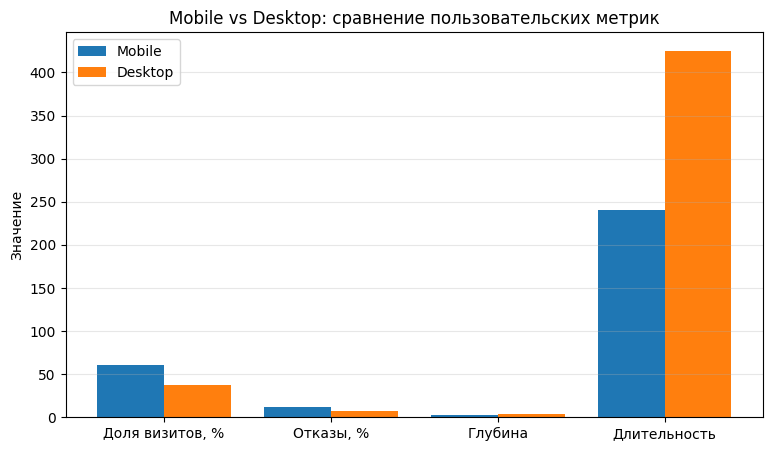

In [507]:
plot_df = mobile_desktop_summary.copy()

plt.figure(figsize=(9, 5))

x = range(len(plot_df))

plt.bar(
    [i - 0.2 for i in x],
    plot_df["Mobile"],
    width=0.4,
    label="Mobile"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_df["Desktop"],
    width=0.4,
    label="Desktop"
)

plt.xticks(
    ticks=x,
    labels=[
        "Доля визитов, %",
        "Отказы, %",
        "Глубина",
        "Длительность"
    ]
)

plt.title("Mobile vs Desktop: сравнение пользовательских метрик")
plt.ylabel("Значение")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

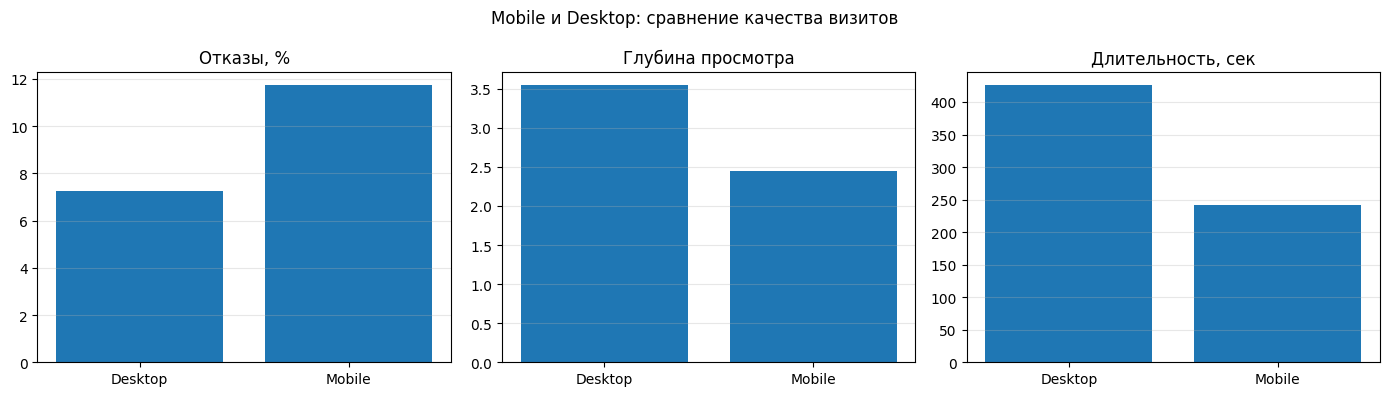

In [489]:
plot_df = device_compare.set_index("device")

metrics = ["bounce_rate_%", "avg_pageviews", "avg_duration"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

titles = [
    "Отказы, %",
    "Глубина просмотра",
    "Длительность, сек"
]

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(plot_df.index, plot_df[metric])
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Mobile и Desktop: сравнение качества визитов")
plt.tight_layout()
plt.show()

In [490]:
program_depth = program_visits["ym:s:pageViews"].mean()
site_depth = visits["ym:s:pageViews"].mean()

depth_summary = pd.DataFrame({
    "Показатель": [
        "Средняя глубина по сайту",
        "Средняя глубина на страницах программ",
        "Отклонение"
    ],
    "Значение": [
        round(site_depth, 2),
        round(program_depth, 2),
        round(program_depth - site_depth, 2)
    ]
})

depth_summary

,Показатель,Значение
0,Средняя глубина по сайту,2.87
1,Средняя глубина на страницах программ,2.53
2,Отклонение,-0.34


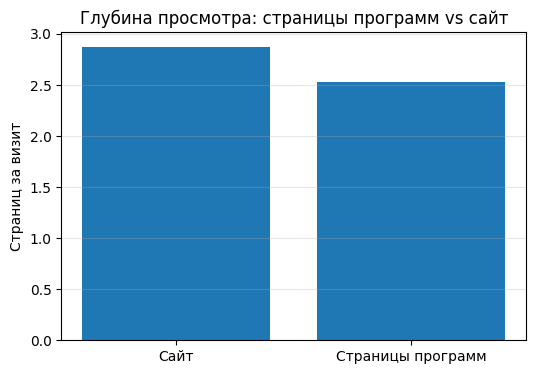

In [491]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Сайт", "Страницы программ"],
    [site_depth, program_depth]
)

plt.title("Глубина просмотра: страницы программ vs сайт")
plt.ylabel("Страниц за визит")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [492]:
program_mask_hits = page_hits["page"].astype(str).str.lower().str.contains(
    "program|programs|base/programs",
    regex=True
)

program_views = program_mask_hits.sum()
total_views = len(page_hits)

program_share = program_views / total_views * 100

program_visits = visits[
    visits["start_page"].astype(str).str.lower().str.contains(
        "program|programs|base/programs",
        regex=True
    )
]

site_depth = visits["ym:s:pageViews"].mean()
program_depth = program_visits["ym:s:pageViews"].mean()

site_bounce = visits["ym:s:bounce"].mean() * 100
program_bounce = program_visits["ym:s:bounce"].mean() * 100

program_argument_df = pd.DataFrame({
    "Показатель": [
        "Доля просмотров страниц программ",
        "Глубина просмотра по сайту",
        "Глубина просмотра на страницах программ",
        "Отказы по сайту",
        "Отказы на страницах программ"
    ],
    "Значение": [
        f"{program_share:.1f}%",
        round(site_depth, 2),
        round(program_depth, 2),
        f"{site_bounce:.1f}%",
        f"{program_bounce:.1f}%"
    ]
})

program_argument_df

,Показатель,Значение
0,Доля просмотров страниц программ,32.5%
1,Глубина просмотра по сайту,2.87
2,Глубина просмотра на страницах программ,2.53
3,Отказы по сайту,10.1%
4,Отказы на страницах программ,10.4%


In [493]:
competition_sections = ["rating", "list", "orders"]

transitions["is_competition_flow"] = (
    transitions["start_section"].isin(competition_sections)
    | transitions["end_section"].isin(competition_sections)
)

competition_transitions = transitions["is_competition_flow"].sum()
total_transitions = len(transitions)

competition_share = competition_transitions / total_transitions * 100

competition_argument_df = pd.DataFrame({
    "Показатель": [
        "Все переходы между разделами",
        "Переходы, связанные с конкурсной информацией",
        "Доля переходов конкурсного сценария"
    ],
    "Значение": [
        total_transitions,
        competition_transitions,
        f"{competition_share:.1f}%"
    ]
})

competition_argument_df

,Показатель,Значение
0,Все переходы между разделами,5654
1,"Переходы, связанные с конкурсной информацией",393
2,Доля переходов конкурсного сценария,7.0%


In [494]:
mobile = device_compare[device_compare["device"] == "Mobile"].iloc[0]
desktop = device_compare[device_compare["device"] == "Desktop"].iloc[0]

program_depth_diff = program_depth - site_depth
program_bounce_diff = program_bounce - site_bounce

evidence_final_df = pd.DataFrame({
    "Решение в макете": [
        "Адаптивный интерфейс",
        "Карточка программы",
        "Блок «Что дальше?»",
        "Единый раздел конкурсной информации",
        "Путь абитуриента"
    ],

    "Метрика": [
        "Доля мобильных визитов",
        "Доля просмотров страниц программ",
        "Глубина просмотра страниц программ",
        "Доля переходов rating/list/orders",
        "Основной маршрут пользователя"
    ],

    "Значение": [
        f"{mobile['share_%']:.1f}%",
        f"{program_share:.1f}%",
        round(program_depth, 2),
        f"{competition_share:.1f}%",
        "Главная → Программы → Рейтинг → Списки → Приказы"
    ],

    "Сравнение": [
        f"Desktop: {desktop['share_%']:.1f}%",
        "От всех просмотров сайта",
        f"Среднее по сайту: {site_depth:.2f}",
        "От всех переходов между разделами",
        "Сценарий распределен между несколькими разделами"
    ],

    "Отклонение / проблема": [
        f"Mobile больше Desktop на {mobile['share_%'] - desktop['share_%']:.1f} п.п.",
        "Страницы программ — один из ключевых сценариев",
        f"{program_depth_diff:.2f} страниц к среднему",
        "Конкурсная информация занимает заметную часть переходов",
        "Пользователь сам собирает путь поступления"
    ],

    "Вывод": [
        "Нужен mobile-first подход",
        "Страницу программы нужно переработать как точку выбора",
        "Нужен следующий шаг после просмотра программы",
        "Рейтинги, списки и приказы нужно объединить логически",
        "Нужен единый путь абитуриента"
    ]
})

evidence_final_df

,Решение в макете,Метрика,Значение,Сравнение,Отклонение / проблема,Вывод
0,Адаптивный интерфейс,Доля мобильных визитов,60.9%,Desktop: 37.9%,Mobile больше Desktop на 23.0 п.п.,Нужен mobile-first подход
1,Карточка программы,Доля просмотров страниц программ,32.5%,От всех просмотров сайта,Страницы программ — один из ключевых сценариев,Страницу программы нужно переработать как точку выбора
2,Блок «Что дальше?»,Глубина просмотра страниц программ,2.53,Среднее по сайту: 2.87,-0.34 страниц к среднему,Нужен следующий шаг после просмотра программы
3,Единый раздел конкурсной информации,Доля переходов rating/list/orders,7.0%,От всех переходов между разделами,Конкурсная информация занимает заметную часть переходов,"Рейтинги, списки и приказы нужно объединить логически"
4,Путь абитуриента,Основной маршрут пользователя,Главная → Программы → Рейтинг → Списки → Приказы,Сценарий распределен между несколькими разделами,Пользователь сам собирает путь поступления,Нужен единый путь абитуриента


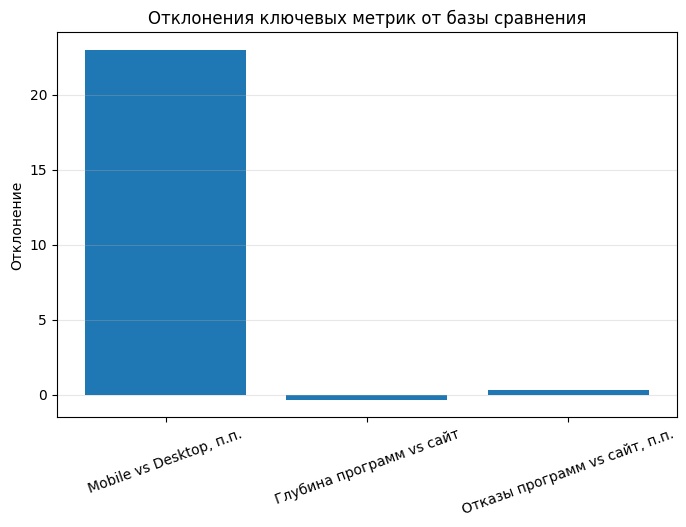

In [495]:
deviation_df = pd.DataFrame({
    "Метрика": [
        "Mobile vs Desktop, п.п.",
        "Глубина программ vs сайт",
        "Отказы программ vs сайт, п.п."
    ],
    "Отклонение": [
        mobile["share_%"] - desktop["share_%"],
        program_depth - site_depth,
        program_bounce - site_bounce
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    deviation_df["Метрика"],
    deviation_df["Отклонение"]
)

plt.title("Отклонения ключевых метрик от базы сравнения")
plt.ylabel("Отклонение")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [500]:
program_mask_hits = page_hits["page"].astype(str).str.lower().str.contains(
    "program|programs|base/programs",
    regex=True
)

program_views = program_mask_hits.sum()
total_views = len(page_hits)
program_share = program_views / total_views * 100

program_visits = visits[
    visits["start_page"].astype(str).str.lower().str.contains(
        "program|programs|base/programs",
        regex=True
    )
]

site_bounce = visits["ym:s:bounce"].mean() * 100
program_bounce = program_visits["ym:s:bounce"].mean() * 100

site_depth = visits["ym:s:pageViews"].mean()
program_depth = program_visits["ym:s:pageViews"].mean()

site_duration = visits["ym:s:visitDuration"].mean()
program_duration = program_visits["ym:s:visitDuration"].mean()

program_compare_df = pd.DataFrame({
    "Что проверяем": [
        "Значимость страниц программ",
        "Отказы на страницах программ",
        "Глубина на страницах программ",
        "Длительность на страницах программ"
    ],
    "Значение": [
        f"{program_share:.1f}% всех просмотров",
        f"{program_bounce:.1f}%",
        round(program_depth, 2),
        f"{program_duration:.0f} сек"
    ],
    "Сравнение": [
        "100% всех просмотров сайта",
        f"{site_bounce:.1f}% в среднем по сайту",
        f"{site_depth:.2f} в среднем по сайту",
        f"{site_duration:.0f} сек в среднем по сайту"
    ],
    "Отклонение": [
        f"{program_share:.1f}% от всех просмотров",
        f"{program_bounce - site_bounce:+.1f} п.п.",
        f"{program_depth - site_depth:+.2f}",
        f"{program_duration - site_duration:+.0f} сек"
    ]
})

program_compare_df

,Что проверяем,Значение,Сравнение,Отклонение
0,Значимость страниц программ,32.5% всех просмотров,100% всех просмотров сайта,32.5% от всех просмотров
1,Отказы на страницах программ,10.4%,10.1% в среднем по сайту,+0.3 п.п.
2,Глубина на страницах программ,2.53,2.87 в среднем по сайту,-0.34
3,Длительность на страницах программ,226 сек,312 сек в среднем по сайту,-86 сек


In [501]:
foreign_mask = visits["start_page"].astype(str).str.lower().str.contains(
    "foreign|international|ino|inostr",
    regex=True
)

foreign_visits = visits[foreign_mask]

site_problem_score = (
    visits["ym:s:bounce"].mean() * 100
    + (1 / visits["ym:s:pageViews"].mean()) * 10
)

foreign_problem_score = (
    foreign_visits["ym:s:bounce"].mean() * 100
    + (1 / foreign_visits["ym:s:pageViews"].mean()) * 10
)

foreign_compare_df = pd.DataFrame({
    "Что проверяем": [
        "Проблемность сценария иностранных абитуриентов",
        "Отказы иностранных абитуриентов",
        "Глубина просмотра иностранных абитуриентов"
    ],
    "Значение": [
        round(foreign_problem_score, 2),
        f"{foreign_visits['ym:s:bounce'].mean() * 100:.1f}%",
        round(foreign_visits["ym:s:pageViews"].mean(), 2)
    ],
    "Сравнение": [
        round(site_problem_score, 2),
        f"{site_bounce:.1f}% в среднем по сайту",
        f"{site_depth:.2f} в среднем по сайту"
    ],
    "Отклонение": [
        f"{foreign_problem_score - site_problem_score:+.2f}",
        f"{foreign_visits['ym:s:bounce'].mean() * 100 - site_bounce:+.1f} п.п.",
        f"{foreign_visits['ym:s:pageViews'].mean() - site_depth:+.2f}"
    ]
})

foreign_compare_df

,Что проверяем,Значение,Сравнение,Отклонение
0,Проблемность сценария иностранных абитуриентов,43.29,13.59,+29.70
1,Отказы иностранных абитуриентов,38.0%,10.1% в среднем по сайту,+27.9 п.п.
2,Глубина просмотра иностранных абитуриентов,1.88,2.87 в среднем по сайту,-0.99


In [506]:
slide_argument_df = pd.DataFrame({
    "Проблемная зона": [
        "Mobile",
        "Страницы программ",
        "Пользовательский путь",
        "Иностранные абитуриенты"
    ],

    "Факт с числом": [
        (
            f"Mobile — {mobile['share_%']:.1f}% визитов "
            f"против {desktop['share_%']:.1f}% Desktop; "
            f"отказы выше на {mobile_summary['bounce_diff']:.1f} п.п., "
            f"глубина ниже на {abs(mobile_summary['pageviews_diff']):.2f}"
        ),
        (
            f"Страницы программ дают {program_share:.1f}% просмотров, "
            f"но глубина ниже средней: {program_depth:.2f} против {site_depth:.2f}"
        ),
        (
            f"{program_to_competition_share:.1f}% переходов со страниц программ "
            f"уходит в rating/list/orders"
        ),
        (
            f"Problem score иностранных абитуриентов: "
            f"{foreign_problem_score:.2f} против {site_problem_score:.2f} по сайту"
        )
    ],

    "Что это доказывает": [
        "Мобильный сценарий массовый, но менее качественный",
        "Страница программы важна, но плохо продолжает сценарий",
        "После выбора программы пользователь уходит в разрозненные конкурсные разделы",
        "Для иностранных абитуриентов нужен отдельный сценарий"
    ],

    "Решение": [
        "Адаптивный интерфейс",
        "Карточка программы + блок «Что дальше?»",
        "Путь абитуриента и единый конкурсный блок",
        "Раздел для иностранных граждан"
    ]
})

slide_argument_df

,Проблемная зона,Факт с числом,Что это доказывает,Решение
0,Mobile,"Mobile — 60.9% визитов против 37.9% Desktop; отказы выше на 4.5 п.п., глубина ниже на 1.09","Мобильный сценарий массовый, но менее качественный",Адаптивный интерфейс
1,Страницы программ,"Страницы программ дают 32.5% просмотров, но глубина ниже средней: 2.53 против 2.87","Страница программы важна, но плохо продолжает сценарий",Карточка программы + блок «Что дальше?»
2,Пользовательский путь,2.6% переходов со страниц программ уходит в rating/list/orders,После выбора программы пользователь уходит в разрозненные конкурсные разделы,Путь абитуриента и единый конкурсный блок
3,Иностранные абитуриенты,Problem score иностранных абитуриентов: 43.29 против 13.59 по сайту,Для иностранных абитуриентов нужен отдельный сценарий,Раздел для иностранных граждан
